In [1]:
import pandas as pd
import numpy as np
from functools import reduce
from scipy.stats import norm
from scipy.optimize import minimize, curve_fit
from statsmodels.tsa.statespace.sarimax import SARIMAX
from hmmlearn import hmm
from scipy.stats import rankdata as _rd, norm as spn
from sklearn.metrics import r2_score
import statsmodels.api as sm
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

## 1. Carga, limpieza de datos y alineación de variables macroeconómicas

In [2]:
import os
BASE = os.path.dirname(os.path.abspath('__file__'))

def load_tiie(path):
    df = pd.read_excel(path, header=1)
    df = df[['Fecha', df.columns[4]]].rename(columns={df.columns[4]: 'TIIE'}).dropna()
    df['Fecha'] = pd.to_datetime(df['Fecha'], format='%b-%Y', errors='coerce') + pd.offsets.MonthEnd(0)
    return df.dropna(subset=['Fecha'])

def load_pib(path):
    df = pd.read_excel(path, header=0, names=['Fecha','PIB'])
    df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce') + pd.offsets.MonthEnd(0)
    return df.dropna()

def load_fx(path):
    raw = pd.read_excel(path, header=None)
    start = next(i for i in range(len(raw)) if pd.notna(raw.iloc[i,0]) and '200' in str(raw.iloc[i,0])[:10])
    df = raw.iloc[start:,:2].rename(columns={0:'Fecha',1:'FX'})
    df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
    df['FX'] = pd.to_numeric(df['FX'], errors='coerce')
    return df.dropna().set_index('Fecha').resample('ME').mean().round(4).reset_index()

def load_gsci(path):
    df = pd.read_excel(path, header=0)
    df['Fecha'] = pd.to_datetime(df.iloc[:,0], errors='coerce', dayfirst=True)
    df['GSCI'] = pd.to_numeric(df.iloc[:,1], errors='coerce')
    return df.dropna(subset=['Fecha','GSCI']).set_index('Fecha')['GSCI'].resample('ME').last().reset_index()

def load_sequia(path):
    df = pd.read_excel(path, header=1)
    df['Fecha'] = pd.to_datetime(df['Fecha'], format='%b-%Y', errors='coerce') + pd.offsets.MonthEnd(0)
    return df[['Fecha','DSCI_Probit']].rename(columns={'DSCI_Probit':'Sequia'}).dropna()

def load_inpc(path):
    df = pd.read_excel(path, header=0, names=['Fecha','INPC'])
    df['Fecha'] = pd.to_datetime(df['Fecha'].astype(str).str.replace('/',''), format='%Y%m', errors='coerce') + pd.offsets.MonthEnd(0)
    return df.dropna()

tiie  = load_tiie(r'C:\Users\rolg0\Downloads\8vo semestre\Administración Integral de Riesgos\Examen 1\Tasa_Interes_Banxico.xlsx')
pib   = load_pib(r'C:\Users\rolg0\Downloads\8vo semestre\Administración Integral de Riesgos\Examen 1\PIB Mensual Actividades primarias.xlsx')
fx    = load_fx(r'C:\Users\rolg0\Downloads\8vo semestre\Administración Integral de Riesgos\Examen 1\Tipo_de_Cambio_Peso_Dolar.xlsx')
gsci  = load_gsci(r'C:\Users\rolg0\Downloads\8vo semestre\Administración Integral de Riesgos\Examen 1\GSCI_Agriculture_2012_2026.xlsx')
spi   = load_sequia(r'C:\Users\rolg0\Downloads\8vo semestre\Administración Integral de Riesgos\Examen 1\Indice_Sequia_Compuesto.xlsx')
inpc  = load_inpc(r'C:\Users\rolg0\Downloads\8vo semestre\Administración Integral de Riesgos\Examen 1\INPC.xlsx')

macro = reduce(lambda a,b: pd.merge(a,b,on='Fecha',how='inner'), [spi,tiie,pib,fx,gsci,inpc])
macro = macro[(macro['Fecha']>='2012-01-01') & (macro['Fecha']<='2026-03-31')].sort_values('Fecha').reset_index(drop=True)

print(f"Macro: {len(macro)} obs | {macro['Fecha'].min().date()} -> {macro['Fecha'].max().date()}")
print(macro.describe().round(4))


Macro: 168 obs | 2012-01-31 -> 2025-12-31
                            Fecha    Sequia      TIIE       PIB        FX  \
count                         168  168.0000  168.0000  168.0000  168.0000   
mean   2019-01-14 16:17:08.571428    0.0207    6.6533   98.3135   17.7426   
min           2012-01-31 00:00:00   -2.5170    3.2878   80.9231   12.2050   
25%           2015-07-23 06:00:00   -0.6469    4.3298   91.7830   15.8254   
50%           2019-01-15 12:00:00    0.0148    6.3633   99.8284   18.6490   
75%           2022-07-07 18:00:00    0.6839    8.4256  104.0418   19.9663   
max           2025-12-31 00:00:00    2.5758   11.5369  120.8377   24.2658   
std                           NaN    0.9942    2.6562    7.9475    2.8565   

            GSCI      INPC  
count   168.0000  168.0000  
mean   1796.0975    4.5088  
min     358.9700    2.1300  
25%     452.6950    3.4925  
50%    1261.7950    4.2400  
75%    3019.2825    4.9975  
max    4510.7100    8.7000  
std    1393.0083    1.4926  


## 2. Cálculo de PD y PCE Histórica

In [4]:
# ------ Ruta CSV -------
datos_empresas = r'C:\Users\rolg0\Downloads\8vo semestre\Administración Integral de Riesgos\Examen 1\Examen_Admon.csv'

# Fecha de corte
fecha_corte = pd.to_datetime(pd.read_csv(datos_empresas, nrows=0).columns[3], dayfirst=True)
print(f"Fecha de corte: {fecha_corte.date()}")

# Cargar datos
base = pd.read_csv(datos_empresas, skiprows=1)
base = base.dropna(axis=1)
base['due_date'] = pd.to_datetime(base['due_date'], dayfirst=True)

# Días y meses de atraso
base['Dias_de_atraso']  = (fecha_corte - base['due_date']).dt.days.clip(lower=0)
base['Meses_de_atraso'] = (base['Dias_de_atraso'] / 30).round(0).astype(int)

# Resumen por bucket de atraso
resumen = base.groupby('Meses_de_atraso')['original_amount'].sum().reset_index().sort_values('Meses_de_atraso')
resumen['Saldo_Acumulado'] = resumen['original_amount'][::-1].cumsum()[::-1]

# Monto de pérdida total (bucket 163 meses)
monto_perdida_total = resumen.loc[resumen['Meses_de_atraso'] == 163, 'Saldo_Acumulado'].values[0]

# Tasa histórica
resumen['Tasa_historica'] = (monto_perdida_total / resumen['Saldo_Acumulado']).clip(upper=1)

# Ajuste exponencial sobre tasas < 1
resumen_grafica = resumen[resumen['Tasa_historica'] < 1].copy()
primer_100 = resumen[resumen['Tasa_historica'] == 1].head(1)
resumen_grafica = pd.concat([resumen_grafica, primer_100])

x_fit = resumen_grafica['Meses_de_atraso'].values
y_fit = resumen_grafica['Tasa_historica'].values
y_fit = np.where(y_fit <= 0, 1e-9, y_fit)
ln_y = np.log(y_fit)
b_exp, ln_a_exp = np.polyfit(x_fit, ln_y, 1)
a_exp = np.exp(ln_a_exp)
r2_exp = r2_score(y_fit, a_exp * np.exp(b_exp * x_fit))
print(f"Ajuste exponencial: PD = {a_exp:.4f} * e^({b_exp:.4f} * x)  |  R² = {r2_exp:.4f}")

# Tasa ajustada y tasa final
resumen['Tasa_ajustada'] = a_exp * np.exp(b_exp * resumen['Meses_de_atraso'])
resumen['Tasa_final'] = np.maximum(resumen['Tasa_ajustada'], resumen['Tasa_historica'])
resumen.loc[resumen['Meses_de_atraso'] == 0, 'Tasa_final'] = resumen.loc[resumen['Meses_de_atraso'] == 0, 'Tasa_ajustada']

# Reserva
resumen['Reserva'] = resumen['Tasa_final'] * resumen['original_amount']
reserva_total = resumen['Reserva'].sum()
print(f"Reserva Total: ${reserva_total:,.2f}")

# PCE histórica por bucket
LGD = 0.45
resumen['PCE_Historica'] = resumen['Reserva'] * LGD

# PCE individual por factura
base = base.merge(resumen[['Meses_de_atraso','Tasa_final']], on='Meses_de_atraso', how='left')
base['mes_vencimiento'] = base['due_date'].dt.to_period('M')
base['PCE'] = base['original_amount'] * base['Tasa_final'] * LGD

# Series mensuales
pce_mensual    = base.groupby('mes_vencimiento')['PCE'].sum().dropna()
tasas_promedio = base.groupby('mes_vencimiento')['Tasa_final'].mean().dropna()

# Serie PD para modelos
tasas_promedio_ts = tasas_promedio.copy()
tasas_promedio_ts.index = tasas_promedio_ts.index.to_timestamp() + pd.offsets.MonthEnd(0)
tasas_promedio_ts.index.name = 'Fecha'
pd_series = tasas_promedio_ts.to_frame('PD').reset_index()
pd_series = pd_series[(pd_series['Fecha'] >= '2012-01-01') & (pd_series['Fecha'] <= '2025-12-31')]

# EAD para PCE: último monto mensual registrado
ead_mensual = base.groupby('mes_vencimiento')['original_amount'].sum()
EAD = ead_mensual.iloc[-1]

# EAD total para VaR/ES: suma de toda la cartera
EAD_total = base['original_amount'].sum()
print(f"EAD total cartera (VaR): ${EAD_total:,.2f}")
print(f"PD serie: {len(pd_series)} obs | {pd_series['Fecha'].min().date()} -> {pd_series['Fecha'].max().date()}")
print(f"EAD (último mes): ${EAD:,.2f}")
resumen.head()

Fecha de corte: 2025-09-30
Ajuste exponencial: PD = 0.0221 * e^(0.0158 * x)  |  R² = 0.5545
Reserva Total: $4,874,779.24
EAD total cartera (VaR): $31,707,045.22
PD serie: 165 obs | 2012-01-31 -> 2025-09-30
EAD (último mes): $93,772.37


,Meses_de_atraso,original_amount,Saldo_Acumulado,Tasa_historica,Tasa_ajustada,Tasa_final,Reserva,PCE_Historica
0,0,34069.89,31707045.22,0.032803,0.022139,0.022139,754.266319,339.419844
1,1,121861.07,31672975.33,0.032838,0.022491,0.032838,4001.702696,1800.766213
2,2,104078.46,31551114.26,0.032965,0.022849,0.032965,3430.953653,1543.929144
3,3,92217.93,31447035.80,0.033074,0.023212,0.033074,3050.031676,1372.514254
4,4,232805.35,31354817.87,0.033171,0.023582,0.033171,7722.490261,3475.120617


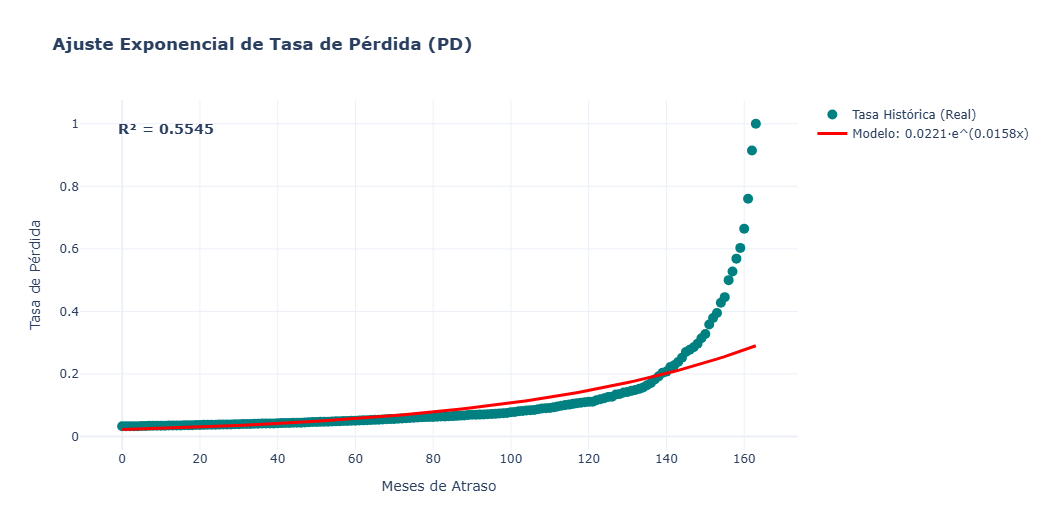

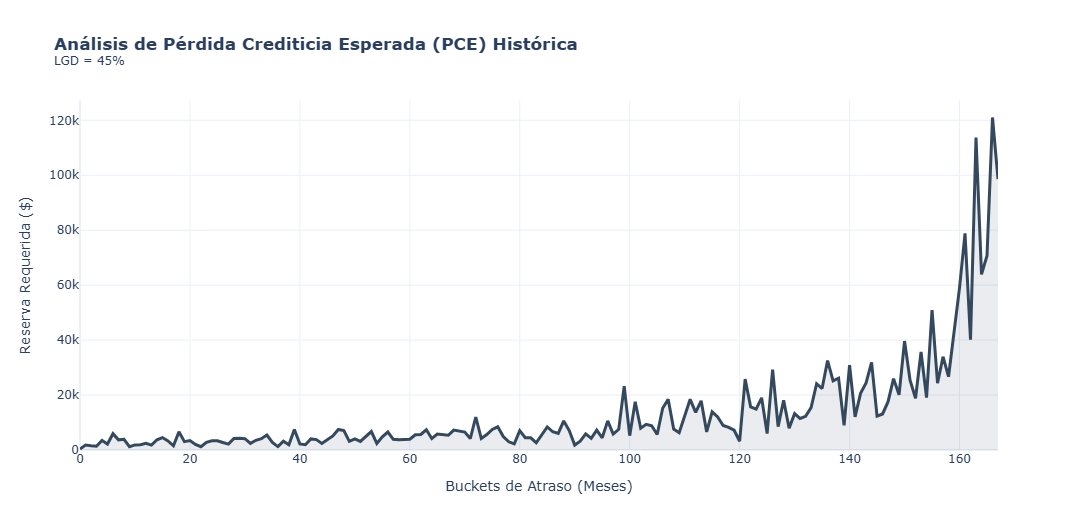

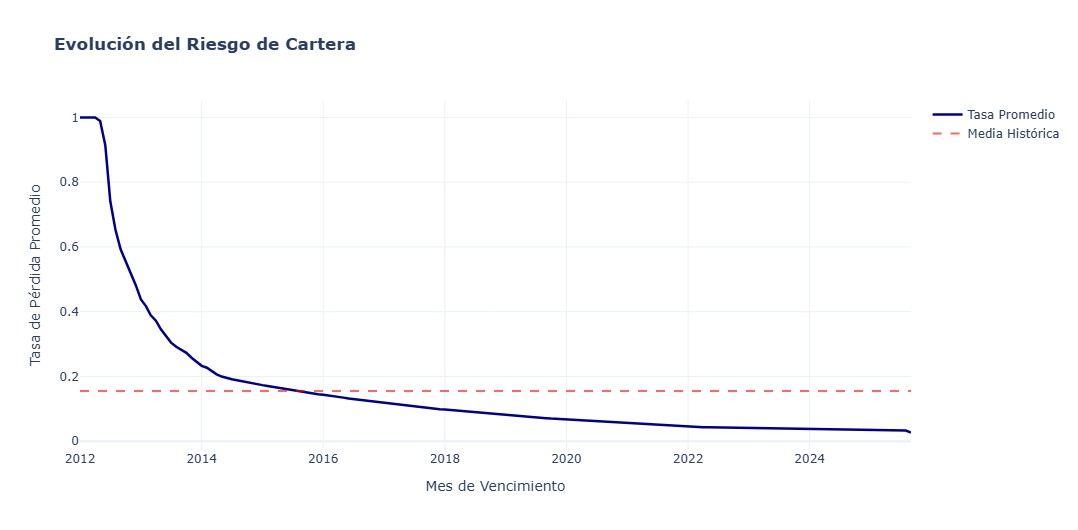

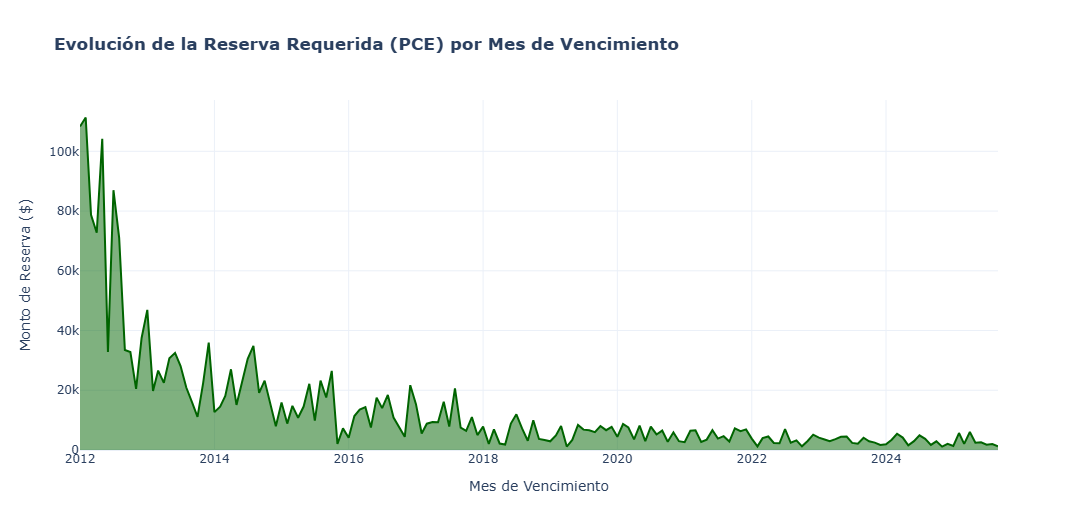

In [5]:
# Gráfica ajuste exponencial
x_range = np.linspace(0, resumen_grafica['Meses_de_atraso'].max(), 100)
y_range = a_exp * np.exp(b_exp * x_range)

fig_ajuste = go.Figure()
fig_ajuste.add_trace(go.Scatter(x=resumen_grafica['Meses_de_atraso'], y=resumen_grafica['Tasa_historica'],
    mode='markers', name='Tasa Histórica (Real)', marker=dict(color='teal', size=10)))
fig_ajuste.add_trace(go.Scatter(x=x_range, y=y_range, mode='lines',
    name=f'Modelo: {a_exp:.4f}·e^({b_exp:.4f}x)', line=dict(color='red', width=3)))
fig_ajuste.update_layout(title='<b>Ajuste Exponencial de Tasa de Pérdida (PD)</b>',
    xaxis_title='Meses de Atraso', yaxis_title='Tasa de Pérdida',
    template='plotly_white', width=1100, height=500,
    annotations=[dict(x=0.05, y=0.95, xref='paper', yref='paper',
        text=f'<b>R² = {r2_exp:.4f}</b>', showarrow=False, font=dict(size=14))])
fig_ajuste.show()

# Gráfica PCE histórica por bucket
fig_pce_bucket = go.Figure()
fig_pce_bucket.add_trace(go.Scatter(x=resumen['Meses_de_atraso'], y=resumen['PCE_Historica'],
    name='PCE Histórica', line=dict(color='#34495e', width=3),
    fill='tozeroy', fillcolor='rgba(52,73,94,0.1)'))
fig_pce_bucket.update_layout(title='<b>Análisis de Pérdida Crediticia Esperada (PCE) Histórica</b><br><sup>LGD = 45%</sup>',
    xaxis_title='Buckets de Atraso (Meses)', yaxis_title='Reserva Requerida ($)',
    template='plotly_white', width=1100, height=500)
fig_pce_bucket.show()

# Evolución temporal de tasa promedio
serie_plot = tasas_promedio.copy()
serie_plot.index = serie_plot.index.to_timestamp()
fig_riesgo = go.Figure()
fig_riesgo.add_trace(go.Scatter(x=serie_plot.index, y=serie_plot.values,
    mode='lines', name='Tasa Promedio', line=dict(color='darkblue', width=2.5)))
fig_riesgo.add_trace(go.Scatter(x=serie_plot.index, y=[serie_plot.mean()]*len(serie_plot),
    mode='lines', name='Media Histórica', line=dict(color='red', width=2, dash='dash'), opacity=0.6))
fig_riesgo.update_layout(title='<b>Evolución del Riesgo de Cartera</b>',
    xaxis_title='Mes de Vencimiento', yaxis_title='Tasa de Pérdida Promedio',
    template='plotly_white', width=1100, height=500)
fig_riesgo.show()

# Evolución temporal PCE mensual
serie_pce_plot = pce_mensual.copy()
serie_pce_plot.index = serie_pce_plot.index.to_timestamp()
fig_pce_ts = go.Figure()
fig_pce_ts.add_trace(go.Scatter(x=serie_pce_plot.index, y=serie_pce_plot.values,
    mode='lines', name='PCE (Reserva en $)', line=dict(color='darkgreen', width=2),
    fill='tozeroy'))
fig_pce_ts.update_layout(title='<b>Evolución de la Reserva Requerida (PCE) por Mes de Vencimiento</b>',
    xaxis_title='Mes de Vencimiento', yaxis_title='Monto de Reserva ($)',
    template='plotly_white', width=1100, height=500)
fig_pce_ts.show()


In [6]:
df = pd.merge(pd_series, macro, on='Fecha', how='inner').sort_values('Fecha').reset_index(drop=True)
print(f"{len(df)} obs | cols: {df.columns.tolist()}")
df.head()


165 obs | cols: ['Fecha', 'PD', 'Sequia', 'TIIE', 'PIB', 'FX', 'GSCI', 'INPC']


,Fecha,PD,Sequia,TIIE,PIB,FX,GSCI,INPC
0,2012-01-31,1.000000,1.1833,4.7861,82.177468,13.4178,4477.27,4.05
1,2012-02-29,1.000000,0.9479,4.7847,83.519812,12.7831,4510.71,3.87
2,2012-03-31,1.000000,0.8165,4.7692,88.343848,12.7567,4376.65,3.73
3,2012-04-30,1.000000,0.7559,4.7443,81.265399,13.0697,4428.37,3.41
4,2012-05-31,0.989276,0.6062,4.7610,80.923056,13.6634,4337.23,3.85


## 3. M1 — SARIMAX + HMM + Vasicek

El modelo se plantea de la siguiente manera. Dado que la probabilidad de incumplimiento $PD_t \in (0,1)$, se aplica la transformación logit para llevarla a soporte real:

$$\text{logit}(PD_t) = \ln\!\left(\frac{PD_t}{1-PD_t}\right)$$

Sobre esta transformación se estima el SARIMAX, incorporando la dinámica temporal de la serie y las variables macroeconómicas como regresores exógenos:

$$\text{logit}(PD_t) = \phi(B)\,\Phi(B^{12}) + \theta(B)\,\Theta(B^{12}) + \boldsymbol{\beta}^\top \mathbf{X}_t + \mu_t^{HMM} + \varepsilon_t$$

donde $\mathbf{X}_t = (\text{Sequía},\, \text{TIIE},\, \text{PIB},\, \text{FX},\, \text{GSCI},\, \text{INPC})^\top$, $B$ es el operador de rezago y $s=12$ corresponde a la estacionalidad mensual. El término $\mu_t^{HMM}$ representa la contribución del régimen económico detectado por el HMM en cada período:

$$\mu_t^{HMM} = E\!\left[\mu^{(k)} \mid \text{estado } k_t\right], \qquad k_t \sim \text{Markov}$$

Finalmente, Vasicek incorpora el factor sistémico ajustando la PD proyectada:

$$PD_t^{sist} = \Phi\!\left(\frac{\Phi^{-1}(PD_t) - \sqrt{\rho}\,Z}{\sqrt{1-\rho}}\right)$$


> **Estrés de escenarios:** El escenario **base** mantiene las variables macro en su último valor observado. El escenario **optimista** aplica mejoras de 1.5–2.0 desviaciones estándar en TIIE, INPC, Sequía y FX, y deterioro en PIB y GSCI de forma inversa. El escenario **pesimista** invierte esos shocks. Vasicek traduce cada trayectoria de PD en una distribución de pérdidas sistémicas mediante el factor de correlación $\rho = 0.15$.

In [7]:
y = df['PD'].clip(0.01, 0.99)
y_logit = np.log(y / (1 - y))
X_cols = ['Sequia','TIIE','PIB','FX','GSCI','INPC']
X = df[X_cols].copy()
X_std = (X - X.mean()) / X.std()

sarimax_model = SARIMAX(y_logit, exog=X_std, order=(1,0,1),
                        seasonal_order=(1,0,1,12),
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(sarimax_model.summary())


                                     SARIMAX Results                                      
Dep. Variable:                                 PD   No. Observations:                  165
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                 359.556
Date:                            Tue, 10 Mar 2026   AIC                           -697.112
Time:                                    01:15:38   BIC                           -663.922
Sample:                                         0   HQIC                          -683.628
                                            - 165                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Sequia         0.0008      0.009      0.085      0.933      -0.017       0.018
TIIE           0.0473      0.049   

In [8]:
H = 12
X_last = X.iloc[-1]

def make_scenario(shocks_std):
    X_fut = pd.DataFrame([X_last] * H, columns=X_cols)
    X_fut_std = (X_fut - X.mean()) / X.std()
    for col, shock in shocks_std.items():
        X_fut_std[col] += shock
    return X_fut_std

X_base = make_scenario({})
X_opt  = make_scenario({'TIIE':-1.5,'FX':-1.0,'INPC':-1.5,'Sequia':-2.0,'PIB':1.0,'GSCI':1.0})
X_pes  = make_scenario({'TIIE':1.5,'FX':2.0,'INPC':2.0,'Sequia':2.5,'PIB':-1.0,'GSCI':-1.5})

def forecast_pd(exog_fut):
    fc_logit = sarimax_model.forecast(H, exog=exog_fut)
    return np.exp(fc_logit) / (1 + np.exp(fc_logit))

sarimax_base = forecast_pd(X_base)
sarimax_opt  = forecast_pd(X_opt)
sarimax_pes  = forecast_pd(X_pes)

fechas_hist = df['Fecha']
fechas_fut  = pd.date_range(fechas_hist.iloc[-1] + pd.offsets.MonthEnd(1), periods=H, freq='ME')
print("SARIMAX base:", np.round(sarimax_base.values, 4))


SARIMAX base: [0.0245 0.0241 0.0237 0.0232 0.0229 0.0225 0.0222 0.0218 0.0215 0.0214
 0.0209 0.0184]


## 4. HMM — Detección de regímenes

In [9]:
serie_hmm = y_logit.values.reshape(-1,1)

mejor_bic, mejor_k = np.inf, 2
for k in [2, 3]:
    m = hmm.GaussianHMM(n_components=k, covariance_type='full', n_iter=1000, random_state=42)
    m.fit(serie_hmm)
    bic = -2*m.score(serie_hmm) + np.log(len(serie_hmm))*(k**2 + 2*k - 1)
    print(f"K={k}  BIC={bic:.2f}")
    if bic < mejor_bic:
        mejor_bic, mejor_k = bic, k

print(f"\nEstados óptimos: {mejor_k}")

hmm_model = hmm.GaussianHMM(n_components=mejor_k, covariance_type='full', n_iter=1000, random_state=42)
hmm_model.fit(serie_hmm)

estados      = hmm_model.predict(serie_hmm)
estado_actual = estados[-1]
medias_hmm   = hmm_model.means_.flatten()
desv_hmm     = np.sqrt([np.diag(hmm_model.covars_[i])[0] for i in range(mejor_k)])
print(f"Estado actual: {estado_actual}  |  Media logit: {medias_hmm[estado_actual]:.4f}")


K=2  BIC=395.63
K=3  BIC=430.99

Estados óptimos: 2
Estado actual: 0  |  Media logit: -2.9988


In [10]:
curr_p = np.zeros(mejor_k); curr_p[estado_actual] = 1.0

escala_base, escala_upper, escala_lower = [], [], []
for _ in range(H):
    curr_p  = curr_p @ hmm_model.transmat_
    mu_t    = np.dot(curr_p, hmm_model.means_.flatten())
    var_t   = np.dot(curr_p, np.array([np.diag(hmm_model.covars_[i])[0] for i in range(mejor_k)]))
    sig_t   = np.sqrt(max(var_t, 0))
    escala_base.append(mu_t)
    escala_upper.append(mu_t + 1.28 * sig_t)
    escala_lower.append(mu_t - 1.28 * sig_t)

inv = lambda x: np.exp(np.array(x)) / (1 + np.exp(np.array(x)))

sarimax_logit_base = np.log(sarimax_base / (1 - sarimax_base))
sarimax_logit_opt  = np.log(sarimax_opt  / (1 - sarimax_opt))
sarimax_logit_pes  = np.log(sarimax_pes  / (1 - sarimax_pes))

pd_compuesta_base  = inv(sarimax_logit_base + np.array(escala_base))
pd_compuesta_upper = inv(sarimax_logit_pes  + np.array(escala_upper))
pd_compuesta_lower = inv(sarimax_logit_opt  + np.array(escala_lower))

print("PD compuesta (SARIMAX+HMM) base:", np.round(pd_compuesta_base, 4))


PD compuesta (SARIMAX+HMM) base: [0.0013 0.0012 0.0012 0.0012 0.0012 0.0011 0.0011 0.0011 0.0011 0.0011
 0.0011 0.0009]


## 5. Ajuste Vasicek a proyecciones

In [11]:
rho = 0.15

def vasicek(pd_arr, Z, rho=0.15):
    return norm.cdf((norm.ppf(np.clip(pd_arr, 1e-6, 1-1e-6)) - np.sqrt(rho)*Z) / np.sqrt(1-rho))

vas_base = vasicek(pd_compuesta_base,  Z=0.0)
vas_opt  = vasicek(pd_compuesta_lower, Z=1.5)
vas_pes  = vasicek(pd_compuesta_upper, Z=-1.5)

print("Vasicek base  (12m):", np.round(vas_base, 4))
print("Vasicek opt   (12m):", np.round(vas_opt,  4))
print("Vasicek pes   (12m):", np.round(vas_pes,  4))


Vasicek base  (12m): [0.0005 0.0005 0.0005 0.0005 0.0005 0.0005 0.0005 0.0005 0.0004 0.0004
 0.0004 0.0004]
Vasicek opt   (12m): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Vasicek pes   (12m): [0.0061 0.006  0.0059 0.0058 0.0057 0.0056 0.0055 0.0054 0.0054 0.0053
 0.0052 0.0046]


## 6. VaR y Expected Shortfall

In [12]:
confianza = 0.99

def var_es_vasicek(pd_escenario, confianza=0.99, EAD=EAD_total, LGD=LGD, rho=0.15, N_sim=100_000):
    pd_mean = np.mean(pd_escenario)
    Z_var = norm.ppf(confianza)
    pd_var_analitico = norm.cdf((norm.ppf(pd_mean) + np.sqrt(rho)*Z_var) / np.sqrt(1-rho))
    VaR_analitico = EAD * LGD * pd_var_analitico
    ES_analitico  = EAD * LGD * norm.cdf(
        (norm.ppf(pd_mean) + np.sqrt(rho)*norm.ppf(confianza)) / np.sqrt(1-rho)) / (1-confianza)
    np.random.seed(42)
    Z_sys = np.random.randn(N_sim)
    pd_condicional = norm.cdf((norm.ppf(pd_mean) - np.sqrt(rho)*Z_sys) / np.sqrt(1-rho))
    perdidas = EAD * LGD * pd_condicional
    VaR_mc = np.percentile(perdidas, confianza*100)
    ES_mc  = perdidas[perdidas >= VaR_mc].mean()
    return {'PD_media':pd_mean,'VaR_analitico':VaR_analitico,'ES_analitico':ES_analitico,
            'VaR_MC':VaR_mc,'ES_MC':ES_mc}

res_base = var_es_vasicek(vas_base)
res_opt  = var_es_vasicek(vas_opt)
res_pes  = var_es_vasicek(vas_pes)

resultados = pd.DataFrame([res_base, res_opt, res_pes],
                          index=['SARIMAX-Base','SARIMAX-Optimista','SARIMAX-Pesimista'])
print(resultados.round(4))


                   PD_media  VaR_analitico  ES_analitico       VaR_MC  \
SARIMAX-Base         0.0005     63808.5462  6.380855e+06   64463.0386   
SARIMAX-Optimista    0.0000      4039.0705  4.039071e+05    4091.5413   
SARIMAX-Pesimista    0.0055    537055.9518  5.370560e+07  541150.4091   

                         ES_MC  
SARIMAX-Base       103153.6401  
SARIMAX-Optimista    7729.2782  
SARIMAX-Pesimista  751289.4796  


## 7. Visualizaciones M1

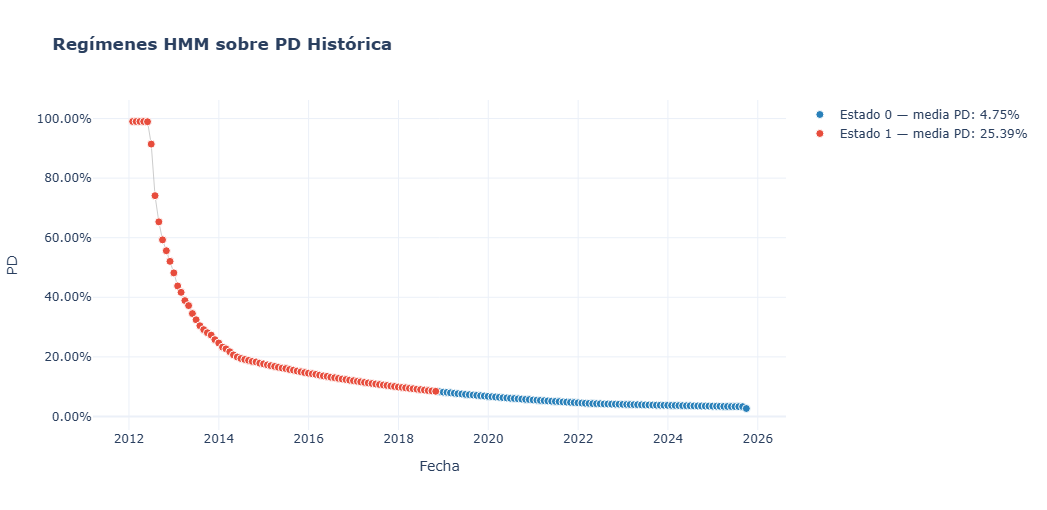

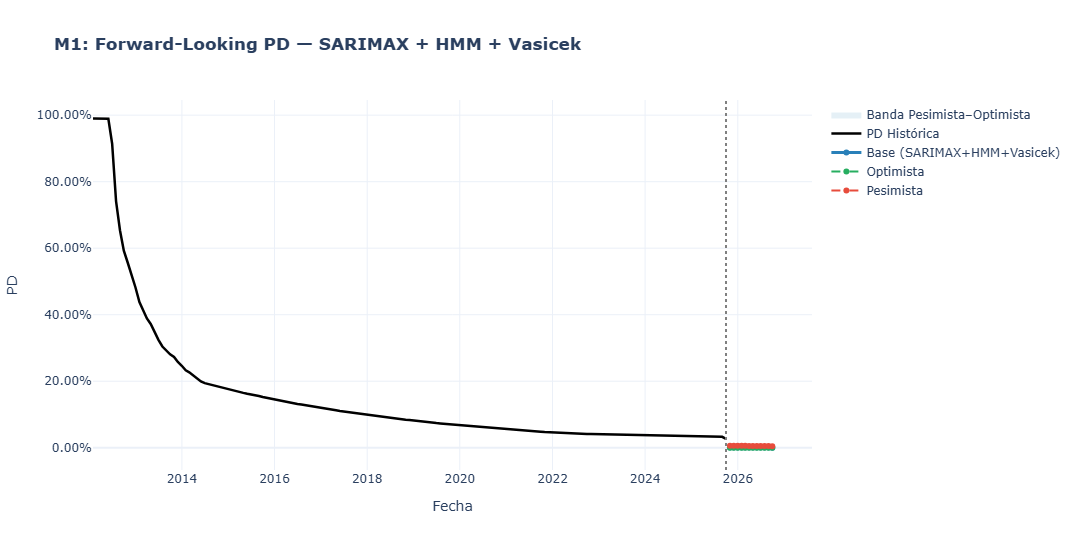

In [63]:
colors_reg = ['#2980b9','#e74c3c','#27ae60']
fig1 = go.Figure()
pd_hist = y.values
fig1.add_trace(go.Scatter(x=fechas_hist, y=pd_hist, mode='lines',
    line=dict(color='gray', width=1), opacity=0.4, showlegend=False))
for i in range(mejor_k):
    mask = estados == i
    fig1.add_trace(go.Scatter(x=fechas_hist[mask], y=pd_hist[mask], mode='markers',
        name=f'Estado {i} — media PD: {inv([medias_hmm[i]])[0]:.2%}',
        marker=dict(size=8, color=colors_reg[i], line=dict(width=1, color='white'))))
fig1.update_layout(title='<b>Regímenes HMM sobre PD Histórica</b>',
    xaxis_title='Fecha', yaxis_title='PD', yaxis_tickformat='.2%',
    template='plotly_white', width=1100, height=480)
fig1.show()

fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=list(fechas_fut)+list(fechas_fut)[::-1],
    y=list(vas_pes)+list(vas_opt)[::-1],
    fill='toself', fillcolor='rgba(41,128,185,0.12)',
    line=dict(color='rgba(0,0,0,0)'), name='Banda Pesimista–Optimista'))
fig2.add_trace(go.Scatter(x=fechas_hist, y=y.values, name='PD Histórica',
    line=dict(color='black', width=2.5)))
fig2.add_trace(go.Scatter(x=fechas_fut, y=vas_base, name='Base (SARIMAX+HMM+Vasicek)',
    line=dict(color='#2980b9', width=3)))
fig2.add_trace(go.Scatter(x=fechas_fut, y=vas_opt, name='Optimista',
    line=dict(color='#27ae60', dash='dash', width=1.8)))
fig2.add_trace(go.Scatter(x=fechas_fut, y=vas_pes, name='Pesimista',
    line=dict(color='#e74c3c', dash='dash', width=1.8)))
fig2.add_vline(x=str(fechas_hist.iloc[-1].date()), line_dash='dot', line_color='gray')
fig2.update_layout(title='<b>M1: Forward-Looking PD — SARIMAX + HMM + Vasicek</b>',
    xaxis_title='Fecha', yaxis_title='PD', yaxis_tickformat='.2%',
    template='plotly_white', width=1100, height=520, hovermode='x unified')
fig2.show()


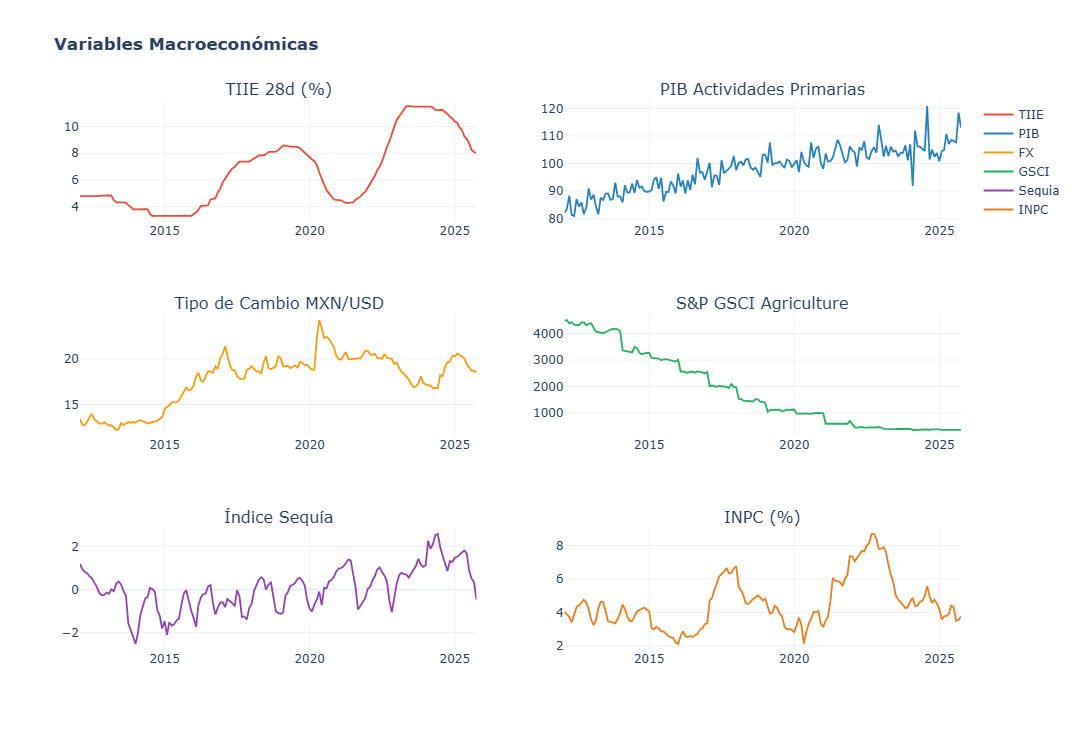

In [14]:
fig4 = make_subplots(rows=3, cols=2,
    subplot_titles=['TIIE 28d (%)','PIB Actividades Primarias',
                    'Tipo de Cambio MXN/USD','S&P GSCI Agriculture',
                    'Índice Sequía','INPC (%)'])
series_cfg = [('TIIE','#e74c3c',1,1),('PIB','#2980b9',1,2),
              ('FX','#f39c12',2,1),('GSCI','#27ae60',2,2),
              ('Sequia','#8e44ad',3,1),('INPC','#e67e22',3,2)]
for col_name, color, row, col in series_cfg:
    fig4.add_trace(go.Scatter(x=df['Fecha'], y=df[col_name], mode='lines',
        name=col_name, line=dict(color=color, width=1.8), showlegend=True), row=row, col=col)
fig4.update_layout(title='<b>Variables Macroeconómicas</b>',
    template='plotly_white', width=1100, height=700)
fig4.show()

## Resumen M1

In [15]:
print("\n Resumen M1")
print("-"*60)
print(f"Periodo histórico : {fechas_hist.iloc[0].date()} → {fechas_hist.iloc[-1].date()}")
print(f"Horizonte proyect.: 12 meses")
print(f"Variables macro   : Sequía, TIIE, PIB, FX, GSCI, INPC")
print(f"Modelos           : SARIMAX(1,0,1)(1,0,1,12) + HMM ({mejor_k} estados) + Vasicek(ρ={rho})")
print()
print(resultados[['PD_media','VaR_MC','ES_MC']].round(6).to_string())



 Resumen M1
------------------------------------------------------------
Periodo histórico : 2012-01-31 → 2025-09-30
Horizonte proyect.: 12 meses
Variables macro   : Sequía, TIIE, PIB, FX, GSCI, INPC
Modelos           : SARIMAX(1,0,1)(1,0,1,12) + HMM (2 estados) + Vasicek(ρ=0.15)

                   PD_media         VaR_MC          ES_MC
SARIMAX-Base       0.000465   64463.038572  103153.640105
SARIMAX-Optimista  0.000023    4091.541340    7729.278232
SARIMAX-Pesimista  0.005528  541150.409135  751289.479635


## 9. M2 — HMM + Regresión + Vasicek

Este modelo sigue la misma lógica de que M1, pero reemplaza el SARIMAX por una regresión OLS, eliminando la estructura temporal explícita pero permitiendo que los coeficientes se recalibren por régimen:

$$\text{logit}(PD_t) = \alpha + \boldsymbol{\beta}^\top \mathbf{X}_t + \mu_t^{HMM} + \varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0,\sigma^2)$$

donde el HMM determina el estado vigente $k_t \sim \text{Markov}$ y aporta el ajuste por régimen $\mu_t^{HMM} = E[\mu^{(k)} \mid \text{estado } k_t]$. Vasicek ajusta la PD proyectada mediante el mismo factor sistémico que M1:

$$PD_t^{sist} = \Phi\!\left(\frac{\Phi^{-1}(PD_t) - \sqrt{\rho}\,Z}{\sqrt{1-\rho}}\right)$$


> **Estrés de escenarios:** El escenario **base** mantiene las variables macro en su último valor observado. El escenario **optimista** aplica mejoras de 1.5–2.0 desviaciones estándar en TIIE, INPC, Sequía y FX, y deterioro en PIB y GSCI de forma inversa. El escenario **pesimista** invierte esos shocks. Vasicek traduce cada trayectoria de PD en una distribución de pérdidas sistémicas mediante el factor de correlación $\rho = 0.15$.

### Diagnóstico M2 — selección de variables

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from itertools import combinations

X_vif = sm.add_constant(X)
vif = pd.DataFrame({'Variable': X_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i+1) for i in range(len(X_cols))]
}).set_index('Variable')
print('VIF:'); print(vif.round(2).to_string())

best_aic, best_vars = np.inf, None
for n in range(1, len(X_cols)+1):
    for combo in combinations(X_cols, n):
        Xc = sm.add_constant(X[list(combo)])
        m  = sm.OLS(y_logit, Xc).fit()
        if m.aic < best_aic:
            best_aic, best_vars = m.aic, combo

X_sel = list(best_vars)
X_ols_sel = sm.add_constant(X[X_sel])
m2_ols_sel = sm.OLS(y_logit, X_ols_sel).fit()
print(f'\nVariables seleccionadas (AIC): {X_sel}')
print(m2_ols_sel.summary())


VIF:
            VIF
Variable       
Sequia     1.63
TIIE       2.75
PIB        5.05
FX         4.11
GSCI      11.69
INPC       1.28

Variables seleccionadas (AIC): ['Sequia', 'TIIE', 'PIB', 'FX', 'GSCI', 'INPC']
                            OLS Regression Results                            
Dep. Variable:                     PD   R-squared:                       0.780
Model:                            OLS   Adj. R-squared:                  0.771
Method:                 Least Squares   F-statistic:                     93.14
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           2.58e-49
Time:                        01:16:22   Log-Likelihood:                -180.05
No. Observations:                 165   AIC:                             374.1
Df Residuals:                     158   BIC:                             395.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                       

In [18]:
m2_ols    = m2_ols_sel
X_cols_m2 = X_sel
print(f'M2 final: {X_cols_m2}')

X_sigma = X.std()

def make_scenario_m2(shocks_std):
    X_fut = pd.DataFrame([X_last] * H, columns=X_cols)
    for col, shock in shocks_std.items():
        X_fut[col] += shock * X_sigma[col]
    return sm.add_constant(X_fut[X_cols_m2], has_constant='add')

X_base_m2 = make_scenario_m2({})
X_opt_m2  = make_scenario_m2({'TIIE':-1.5,'FX':-1.0,'INPC':-1.5,'Sequia':-2.0,'PIB':1.0,'GSCI':1.0})
X_pes_m2  = make_scenario_m2({'TIIE':1.5,'FX':2.0,'INPC':2.0,'Sequia':2.5,'PIB':-1.0,'GSCI':-1.5})

def forecast_ols(X_sc):
    fc_logit = m2_ols.predict(X_sc)
    return np.exp(fc_logit) / (1 + np.exp(fc_logit))

ols_base = forecast_ols(X_base_m2)
ols_opt  = forecast_ols(X_opt_m2)
ols_pes  = forecast_ols(X_pes_m2)


M2 final: ['Sequia', 'TIIE', 'PIB', 'FX', 'GSCI', 'INPC']


In [19]:
serie_hmm_m2 = y_logit.values.reshape(-1, 1)

mejor_bic_m2, mejor_k_m2 = np.inf, 2
for k in [2, 3]:
    m = hmm.GaussianHMM(n_components=k, covariance_type='full', n_iter=1000, random_state=42)
    m.fit(serie_hmm_m2)
    bic = -2*m.score(serie_hmm_m2) + np.log(len(serie_hmm_m2))*(k**2 + 2*k - 1)
    if bic < mejor_bic_m2:
        mejor_bic_m2, mejor_k_m2 = bic, k

hmm_m2 = hmm.GaussianHMM(n_components=mejor_k_m2, covariance_type='full', n_iter=1000, random_state=42)
hmm_m2.fit(serie_hmm_m2)
estados_m2    = hmm_m2.predict(serie_hmm_m2)
estado_act_m2 = estados_m2[-1]
medias_m2     = hmm_m2.means_.flatten()

curr_p = np.zeros(mejor_k_m2); curr_p[estado_act_m2] = 1.0
esc_base_m2, esc_upper_m2, esc_lower_m2 = [], [], []
for _ in range(H):
    curr_p = curr_p @ hmm_m2.transmat_
    mu_t   = np.dot(curr_p, medias_m2)
    var_t  = np.dot(curr_p, np.array([np.diag(hmm_m2.covars_[i])[0] for i in range(mejor_k_m2)]))
    sig_t  = np.sqrt(max(var_t, 0))
    esc_base_m2.append(mu_t)
    esc_upper_m2.append(mu_t + 1.28*sig_t)
    esc_lower_m2.append(mu_t - 1.28*sig_t)

ols_logit_base = np.log(np.clip(ols_base, 1e-6, 1-1e-6) / (1 - np.clip(ols_base, 1e-6, 1-1e-6)))
ols_logit_opt  = np.log(np.clip(ols_opt,  1e-6, 1-1e-6) / (1 - np.clip(ols_opt,  1e-6, 1-1e-6)))
ols_logit_pes  = np.log(np.clip(ols_pes,  1e-6, 1-1e-6) / (1 - np.clip(ols_pes,  1e-6, 1-1e-6)))

pd_m2_base  = inv(np.array(ols_logit_base) + np.array(esc_base_m2))
pd_m2_lower = inv(np.array(ols_logit_opt)  + np.array(esc_lower_m2))
pd_m2_upper = inv(np.array(ols_logit_pes)  + np.array(esc_upper_m2))


### Vasicek M2

In [20]:
vas_m2_base = vasicek(pd_m2_base,  Z=0.0)
vas_m2_opt  = vasicek(pd_m2_lower, Z=1.5)
vas_m2_pes  = vasicek(pd_m2_upper, Z=-1.5)

print('Vasicek M2 base:', np.round(vas_m2_base, 4))
print('Vasicek M2 opt: ', np.round(vas_m2_opt,  4))
print('Vasicek M2 pes: ', np.round(vas_m2_pes,  4))


Vasicek M2 base: [0.0002 0.0002 0.0002 0.0002 0.0002 0.0002 0.0002 0.0002 0.0002 0.0002
 0.0002 0.0002]
Vasicek M2 opt:  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Vasicek M2 pes:  [0.0027 0.0027 0.0027 0.0027 0.0027 0.0027 0.0027 0.0027 0.0027 0.0027
 0.0027 0.0027]


### VaR y Expected Shortfall M2

In [21]:
res_m2_base = var_es_vasicek(vas_m2_base)
res_m2_opt  = var_es_vasicek(vas_m2_opt)
res_m2_pes  = var_es_vasicek(vas_m2_pes)

resultados_m2 = pd.DataFrame([res_m2_base, res_m2_opt, res_m2_pes],
    index=['M2-Base','M2-Optimista','M2-Pesimista'])
print(resultados_m2.round(4).to_string())


              PD_media  VaR_analitico  ES_analitico       VaR_MC        ES_MC
M2-Base         0.0002     29526.6120  2.952661e+06   29853.7320   50108.1930
M2-Optimista    0.0000      1262.4082  1.262408e+05    1280.0841    2585.5010
M2-Pesimista    0.0027    290527.6750  2.905277e+07  292983.2195  424610.4118


### Visualizaciones M2

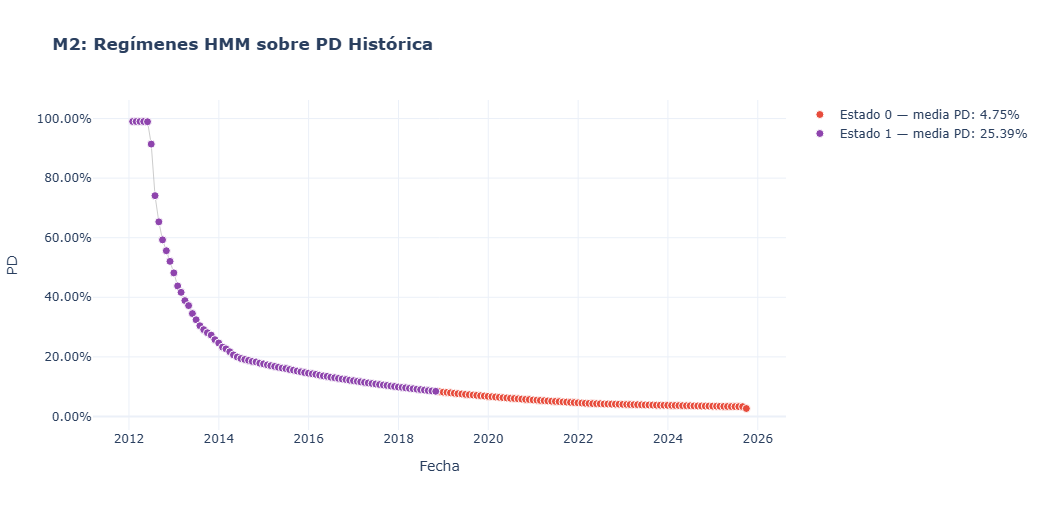

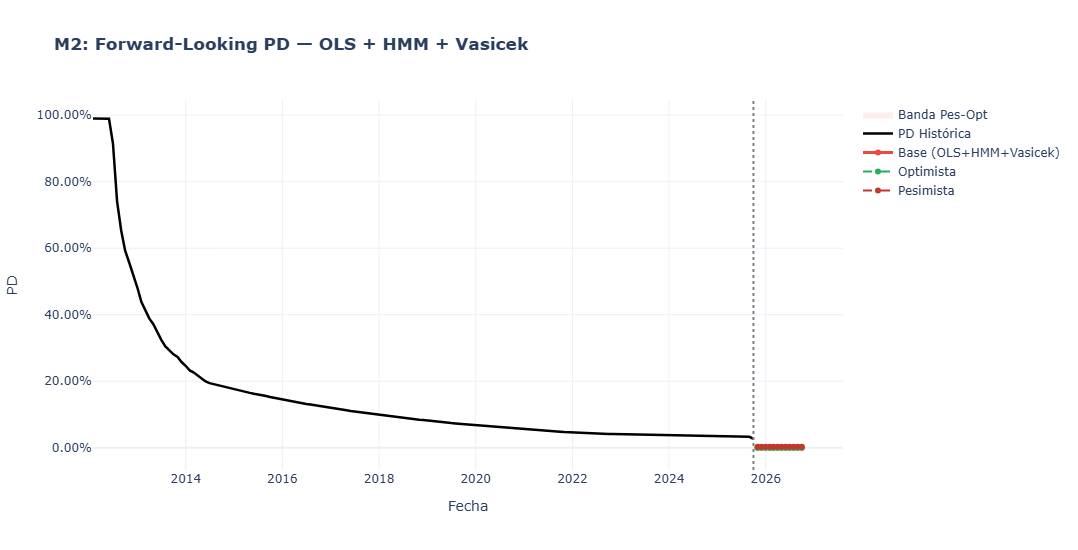

In [62]:
fechas_fut_m2 = pd.date_range(fechas_hist.iloc[-1]+pd.offsets.MonthEnd(1), periods=H, freq='ME')

colors_m2 = ['#e74c3c','#8e44ad','#f39c12']
fig_m2_reg = go.Figure()
fig_m2_reg.add_trace(go.Scatter(x=fechas_hist, y=y.values, mode='lines',
    line=dict(color='gray', width=1), opacity=0.4, showlegend=False))
for i in range(mejor_k_m2):
    mask = estados_m2 == i
    fig_m2_reg.add_trace(go.Scatter(x=fechas_hist[mask], y=y.values[mask], mode='markers',
        name=f'Estado {i} — media PD: {inv([medias_m2[i]])[0]:.2%}',
        marker=dict(size=8, color=colors_m2[i], line=dict(width=1, color='white'))))
fig_m2_reg.update_layout(title='<b>M2: Regímenes HMM sobre PD Histórica</b>',
    xaxis_title='Fecha', yaxis_title='PD', yaxis_tickformat='.2%',
    template='plotly_white', width=1100, height=480)
fig_m2_reg.show()

fig_m2_fl = go.Figure()
fig_m2_fl.add_trace(go.Scatter(x=list(fechas_fut_m2)+list(fechas_fut_m2)[::-1],
    y=list(vas_m2_pes)+list(vas_m2_opt)[::-1],
    fill='toself', fillcolor='rgba(231,76,60,0.10)',
    line=dict(color='rgba(0,0,0,0)'), name='Banda Pes-Opt'))
fig_m2_fl.add_trace(go.Scatter(x=fechas_hist, y=y.values, name='PD Histórica',
    line=dict(color='black', width=2.5)))
fig_m2_fl.add_trace(go.Scatter(x=fechas_fut_m2, y=vas_m2_base,
    name='Base (OLS+HMM+Vasicek)', line=dict(color='#e74c3c', width=3)))
fig_m2_fl.add_trace(go.Scatter(x=fechas_fut_m2, y=vas_m2_opt,
    name='Optimista', line=dict(color='#27ae60', dash='dash', width=1.8)))
fig_m2_fl.add_trace(go.Scatter(x=fechas_fut_m2, y=vas_m2_pes,
    name='Pesimista', line=dict(color='#c0392b', dash='dash', width=1.8)))
fig_m2_fl.add_vline(x=str(fechas_hist.iloc[-1].date()), line_dash='dot', line_color='gray')
fig_m2_fl.update_layout(title='<b>M2: Forward-Looking PD — OLS + HMM + Vasicek</b>',
    xaxis_title='Fecha', yaxis_title='PD', yaxis_tickformat='.2%',
    template='plotly_white', width=1100, height=520, hovermode='x unified')
fig_m2_fl.show()



## 10. M3 — Regresión + Cópulas + Vasicek

A diferencia de los modelos anteriores, este modelo transforma cada variable a espacio uniforme mediante su distribución empírica y posteriormente al espacio gaussiano de la cópula:

$$U_{j,t} = \frac{\text{rank}(x_{j,t})}{n+1}, \qquad Z_{j,t} = \Phi^{-1}(U_{j,t})$$

Sobre ese espacio se estima una regresión OLS que captura la dependencia conjunta entre la PD y las variables macroeconómicas transformadas:

$$\hat{Z}_{PD,t} = \alpha + \boldsymbol{\gamma}^\top \mathbf{Z}_{X,t} + \varepsilon_t, \qquad \mathbf{Z}_{X,t} = \Phi^{-1}\!\left(\hat{F}_j(\mathbf{X}_t)\right)$$

donde $\mathbf{X}_t = (\text{Sequía},\, \text{TIIE},\, \text{PIB},\, \text{FX},\, \text{GSCI},\, \text{INPC})^\top$. La proyección se invierte a escala original mediante:

$$\widehat{PD}_t = \hat{F}_{PD}^{-1}\!\left(\Phi(\hat{Z}_{PD,t})\right)$$

Vasicek ajusta la PD proyectada con el mismo factor sistémico que M1 y M2:

$$PD_t^{sist} = \Phi\!\left(\frac{\Phi^{-1}(\widehat{PD}_t) - \sqrt{\rho}\,Z}{\sqrt{1-\rho}}\right)$$


> **Estrés de escenarios:** El escenario **base** mantiene las variables macro en su último valor observado. El escenario **optimista** aplica mejoras de 1.5–2.0 desviaciones estándar en TIIE, INPC, Sequía y FX, y deterioro en PIB y GSCI de forma inversa. El escenario **pesimista** invierte esos shocks. Vasicek traduce cada trayectoria de PD en una distribución de pérdidas sistémicas mediante el factor de correlación $\rho = 0.15$.

In [23]:
def emp_uniform(x):
    return _rd(x) / (len(x) + 1)

def cond_uniform(x_new, x_ref):
    combined = np.concatenate([x_ref, x_new])
    return _rd(combined)[len(x_ref):] / (len(combined) + 1)

cols_c   = ['PD'] + X_cols
data_c   = df[cols_c].copy()
data_c['PD'] = y.values
Z_full   = data_c.apply(lambda s: spn.ppf(emp_uniform(s)))

Z_X_full = Z_full[X_cols]
Z_y_full = Z_full['PD']
m3_reg   = sm.OLS(Z_y_full, sm.add_constant(Z_X_full)).fit()
print(m3_reg.summary())


                            OLS Regression Results                            
Dep. Variable:                     PD   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     1055.
Date:                Tue, 10 Mar 2026   Prob (F-statistic):          1.08e-124
Time:                        01:16:43   Log-Likelihood:                 77.248
No. Observations:                 165   AIC:                            -140.5
Df Residuals:                     158   BIC:                            -118.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0010      0.012     -0.082      0.9

### Escenarios forward-looking M3

In [24]:
def escenario_m3(shocks_std):
    X_fut = pd.DataFrame([X_last] * H, columns=X_cols)
    X_fut_std = (X_fut - X.mean()) / X.std()
    for col, shock in shocks_std.items():
        X_fut_std[col] += shock
    Z_fut = pd.DataFrame({
        c: spn.ppf(cond_uniform(X_fut_std[c].values, Z_X_full[c].values))
        for c in X_cols})
    Z_pd_pred = m3_reg.predict(sm.add_constant(Z_fut, has_constant='add'))
    U_pd = spn.cdf(Z_pd_pred)
    return np.clip(np.quantile(y.values, np.clip(U_pd, 0.01, 0.99)), 1e-6, 1-1e-6)

pd_m3_base = escenario_m3({})
pd_m3_opt  = escenario_m3({'TIIE':-1.5,'FX':-1.0,'INPC':-1.5,'Sequia':-2.0,'PIB':1.0,'GSCI':1.0})
pd_m3_pes  = escenario_m3({'TIIE':1.5,'FX':2.0,'INPC':2.0,'Sequia':2.5,'PIB':-1.0,'GSCI':-1.5})


### Vasicek M3

In [25]:
vas_m3_base = vasicek(pd_m3_base, Z=0.0)
vas_m3_opt  = vasicek(pd_m3_opt,  Z=1.5)
vas_m3_pes  = vasicek(pd_m3_pes,  Z=-1.5)

print('Vasicek M3 base:', np.round(vas_m3_base, 4))
print('Vasicek M3 opt: ', np.round(vas_m3_opt,  4))
print('Vasicek M3 pes: ', np.round(vas_m3_pes,  4))


Vasicek M3 base: [0.027 0.027 0.027 0.027 0.027 0.027 0.027 0.027 0.027 0.027 0.027 0.027]
Vasicek M3 opt:  [0.0101 0.0101 0.0101 0.0101 0.0101 0.0101 0.0101 0.0101 0.0101 0.0101
 0.0101 0.0101]
Vasicek M3 pes:  [0.0896 0.0896 0.0896 0.0896 0.0896 0.0896 0.0896 0.0896 0.0896 0.0896
 0.0896 0.0896]


### VaR y Expected Shortfall M3

In [26]:
res_m3_base = var_es_vasicek(vas_m3_base)
res_m3_opt  = var_es_vasicek(vas_m3_opt)
res_m3_pes  = var_es_vasicek(vas_m3_pes)

resultados_m3 = pd.DataFrame([res_m3_base, res_m3_opt, res_m3_pes],
    index=['M3-Base','M3-Optimista','M3-Pesimista'])
print(resultados_m3.round(4).to_string())


              PD_media  VaR_analitico  ES_analitico        VaR_MC         ES_MC
M3-Base         0.0270   1.898211e+06  1.898211e+08  1.908930e+06  2.405780e+06
M3-Optimista    0.0101   8.792622e+05  8.792622e+07  8.853326e+05  1.185474e+06
M3-Pesimista    0.0896   4.504483e+06  4.504483e+08  4.522195e+06  5.273236e+06


### Visualizaciones M3

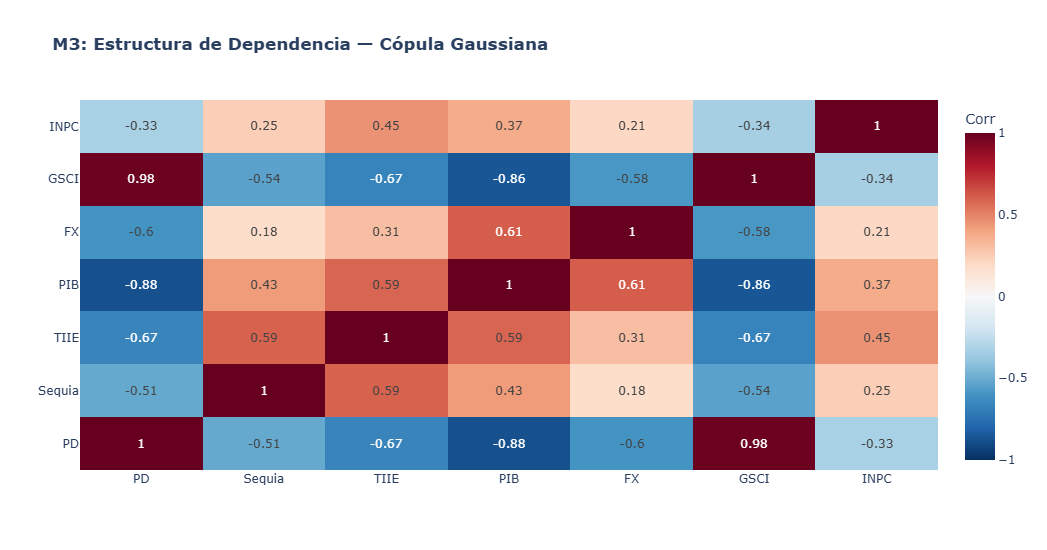

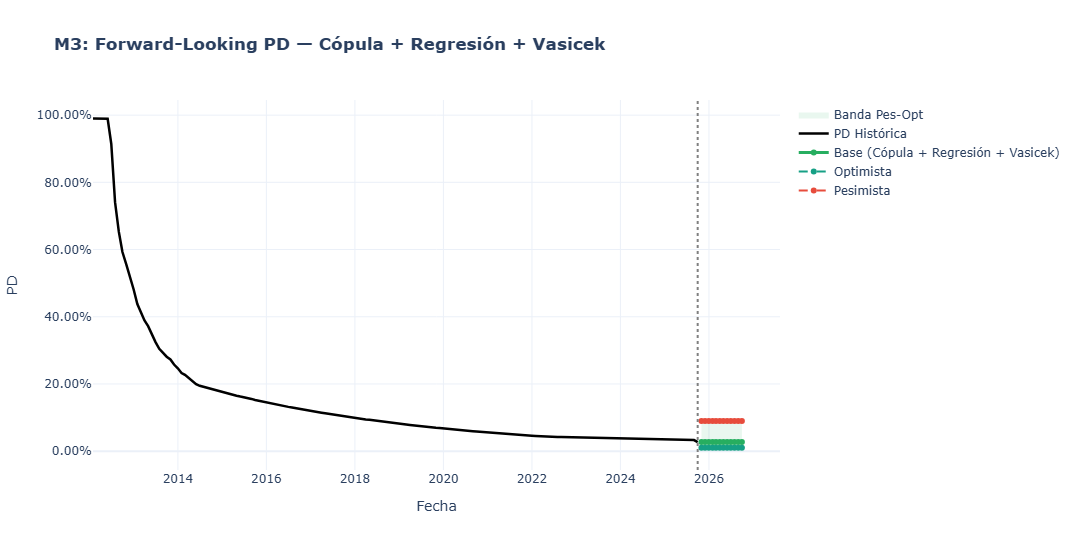

In [61]:
fechas_fut_m3 = pd.date_range(fechas_hist.iloc[-1]+pd.offsets.MonthEnd(1), periods=H, freq='ME')

corr_full = Z_full.corr()
fig_cop = go.Figure(go.Heatmap(z=corr_full.values,
    x=corr_full.columns.tolist(), y=corr_full.index.tolist(),
    colorscale='RdBu_r', zmid=0,
    text=np.round(corr_full.values, 2), texttemplate='%{text}',
    colorbar=dict(title='Corr')))
fig_cop.update_layout(title='<b>M3: Estructura de Dependencia — Cópula Gaussiana</b>',
    template='plotly_white', width=650, height=550)
fig_cop.show()

fig_m3_fl = go.Figure()
fig_m3_fl.add_trace(go.Scatter(x=list(fechas_fut_m3)+list(fechas_fut_m3)[::-1],
    y=list(vas_m3_pes)+list(vas_m3_opt)[::-1],
    fill='toself', fillcolor='rgba(39,174,96,0.10)',
    line=dict(color='rgba(0,0,0,0)'), name='Banda Pes-Opt'))
fig_m3_fl.add_trace(go.Scatter(x=fechas_hist, y=y.values, name='PD Histórica',
    line=dict(color='black', width=2.5)))
fig_m3_fl.add_trace(go.Scatter(x=fechas_fut_m3, y=vas_m3_base,
    name='Base (Cópula + Regresión + Vasicek)', line=dict(color='#27ae60', width=3)))
fig_m3_fl.add_trace(go.Scatter(x=fechas_fut_m3, y=vas_m3_opt,
    name='Optimista', line=dict(color='#16a085', dash='dash', width=1.8)))
fig_m3_fl.add_trace(go.Scatter(x=fechas_fut_m3, y=vas_m3_pes,
    name='Pesimista', line=dict(color='#e74c3c', dash='dash', width=1.8)))
fig_m3_fl.add_vline(x=str(fechas_hist.iloc[-1].date()), line_dash='dot', line_color='gray')
fig_m3_fl.update_layout(title='<b>M3: Forward-Looking PD — Cópula + Regresión + Vasicek</b>',
    xaxis_title='Fecha', yaxis_title='PD', yaxis_tickformat='.2%',
    template='plotly_white', width=1100, height=520, hovermode='x unified')
fig_m3_fl.show()


## 11. M4 — SARIMAX + Cópulas + HMM + Vasicek
### *Modelo principal de proyección forward-looking*

Como modelo principal de proyección forward-looking, M4 ensambla los tres componentes de forma secuencial, donde cada uno modela lo que el anterior no captura. El SARIMAX proyecta la dinámica temporal sobre el logit de la PD:

$$\text{logit}(PD_t) = \phi(B)\,\Phi(B^{12}) + \theta(B)\,\Theta(B^{12}) + \boldsymbol{\beta}^\top \mathbf{X}_t + \varepsilon_t^{SAR}$$

La cópula captura la dependencia no lineal remanente en los residuos $\varepsilon_t^{SAR}$, y el HMM detecta el régimen sobre los residuos corregidos $r_t = \varepsilon_t^{SAR} - \hat{\varepsilon}_t^{cop}$. La PD compuesta final se obtiene como:

$$\widehat{PD}_t^{M4} = \sigma\!\left(\hat{y}_t^{SAR} + \hat{\varepsilon}_t^{cop} + \mu_t^{HMM}\right), \qquad \sigma(x) = \frac{e^x}{1+e^x}$$

Por último, Vasicek incorpora el factor sistémico:

$$PD_t^{sist} = \Phi\!\left(\frac{\Phi^{-1}(\widehat{PD}_t^{M4}) - \sqrt{\rho}\,Z}{\sqrt{1-\rho}}\right)$$


> **Estrés de escenarios:** El escenario **base** mantiene las variables macro en su último valor observado. El escenario **optimista** aplica mejoras de 1.5–2.0 desviaciones estándar en TIIE, INPC, Sequía y FX, y deterioro en PIB y GSCI de forma inversa. El escenario **pesimista** invierte esos shocks. Vasicek traduce cada trayectoria de PD en una distribución de pérdidas sistémicas mediante el factor de correlación $\rho = 0.15$.

### Cópula Gaussiana sobre residuos SARIMAX

In [28]:
resid_sar  = sarimax_model.resid.values
fitted_sar = sarimax_model.fittedvalues.values
n_resid    = len(resid_sar)
X_aligned  = X_std.iloc[-n_resid:].reset_index(drop=True)

resid_std = (resid_sar - resid_sar.mean()) / resid_sar.std()
data_cop  = pd.DataFrame({'resid': resid_std})
for c in X_cols:
    data_cop[c] = X_aligned[c].values

Z_cop          = data_cop.apply(lambda s: spn.ppf(emp_uniform(s)))
Sigma_cop      = Z_cop.corr().values
Sig_r_X        = Sigma_cop[0, 1:]
Sig_XX_cop     = Sigma_cop[1:, 1:]
Sig_XX_cop_inv = np.linalg.inv(Sig_XX_cop)

eps_cop_hist = np.quantile(resid_sar,
    np.clip(spn.cdf(Z_cop[X_cols].values @ Sig_XX_cop_inv @ Sig_r_X), 0.01, 0.99))
resid_corregido = resid_sar - eps_cop_hist

corr_resid = pd.Series([np.corrcoef(resid_sar, X_std[c].values)[0,1] for c in X_cols], index=X_cols)
print('Correlacion residuos SARIMAX con macro:')
print(corr_resid.round(4).to_string())


Correlacion residuos SARIMAX con macro:
Sequia    0.0693
TIIE      0.0185
PIB      -0.0100
FX        0.0258
GSCI     -0.0235
INPC     -0.0027


### HMM sobre residuos corregidos

In [29]:
serie_hmm_m4 = resid_corregido.reshape(-1, 1)

mejor_bic_m4, mejor_k_m4 = np.inf, 2
for k in [2, 3]:
    m = hmm.GaussianHMM(n_components=k, covariance_type='full', n_iter=1000, random_state=42)
    m.fit(serie_hmm_m4)
    bic_k = -2*m.score(serie_hmm_m4) + np.log(len(serie_hmm_m4))*(k**2 + 2*k - 1)
    print(f'K={k}  BIC={bic_k:.2f}')
    if bic_k < mejor_bic_m4:
        mejor_bic_m4, mejor_k_m4 = bic_k, k

print(f'\nEstados óptimos M4: {mejor_k_m4}')

hmm_m4 = hmm.GaussianHMM(n_components=mejor_k_m4, covariance_type='full', n_iter=1000, random_state=42)
hmm_m4.fit(serie_hmm_m4)
estados_m4    = hmm_m4.predict(serie_hmm_m4)
estado_act_m4 = estados_m4[-1]
medias_m4     = hmm_m4.means_.flatten()
desv_m4       = np.sqrt([np.diag(hmm_m4.covars_[i])[0] for i in range(mejor_k_m4)])

print(f'Estado actual M4: {estado_act_m4}')
print(f'Medias por estado: {np.round(medias_m4, 4)}')


K=2  BIC=-24.15
K=3  BIC=-793.13

Estados óptimos M4: 3
Estado actual M4: 2
Medias por estado: [-4.000e-04  4.613e+00 -3.614e-01]


### Escenarios forward-looking M4

In [30]:
def proj_m4(shocks_std):
    X_fut = pd.DataFrame([X_last] * H, columns=X_cols)
    X_fut_std = (X_fut - X.mean()) / X.std()
    for col, shock in shocks_std.items():
        X_fut_std[col] += shock
    fc_sar = sarimax_model.forecast(H, exog=X_fut_std).values

    eps_cop_fut = np.zeros(H)
    for t in range(H):
        z_x_t = np.array([
            spn.ppf(cond_uniform(np.array([X_fut_std[c].iloc[t]]), X_aligned[c].values)[0])
            for c in X_cols])
        z_resid_t = Sig_r_X @ Sig_XX_cop_inv @ z_x_t
        eps_cop_fut[t] = np.quantile(resid_sar, np.clip(spn.cdf(z_resid_t), 0.01, 0.99))

    curr_p = np.zeros(mejor_k_m4); curr_p[estado_act_m4] = 1.0
    esc_b, esc_u, esc_l = [], [], []
    for _ in range(H):
        curr_p = curr_p @ hmm_m4.transmat_
        mu_t   = np.dot(curr_p, medias_m4)
        var_t  = np.dot(curr_p, desv_m4**2 + medias_m4**2) - mu_t**2
        sig_t  = np.sqrt(max(var_t, 0))
        esc_b.append(mu_t); esc_u.append(mu_t + 1.28*sig_t); esc_l.append(mu_t - 1.28*sig_t)

    inv_l = lambda x: np.exp(np.array(x)) / (1 + np.exp(np.array(x)))
    pd_b = np.clip(inv_l(fc_sar + eps_cop_fut + np.array(esc_b)), 1e-6, 1-1e-6)
    pd_u = np.clip(inv_l(fc_sar + eps_cop_fut + np.array(esc_u)), 1e-6, 1-1e-6)
    pd_l = np.clip(inv_l(fc_sar + eps_cop_fut + np.array(esc_l)), 1e-6, 1-1e-6)
    return pd_b, pd_u, pd_l

m4_base, m4_bu, m4_bl = proj_m4({})
m4_pes,  m4_pu, m4_pl = proj_m4({'TIIE':1.5,'FX':2.0,'INPC':2.0,'Sequia':2.5,'PIB':-1.0,'GSCI':-1.5})
m4_opt,  m4_ou, m4_ol = proj_m4({'TIIE':-1.5,'FX':-1.0,'INPC':-1.5,'Sequia':-2.0,'PIB':1.0,'GSCI':1.0})

print('M4 base:', np.round(m4_base, 4))

M4 base: [0.0178 0.0179 0.018  0.018  0.0181 0.018  0.0181 0.018  0.018  0.018
 0.0179 0.0158]


### Vasicek M4

In [31]:
vas_m4_base = vasicek(m4_base, Z=0.0)
vas_m4_opt  = vasicek(m4_opt,  Z=1.5)
vas_m4_pes  = vasicek(m4_pes,  Z=-1.5)

print('Vasicek M4 base:', np.round(vas_m4_base, 4))
print('Vasicek M4 opt: ', np.round(vas_m4_opt,  4))
print('Vasicek M4 pes: ', np.round(vas_m4_pes,  4))
print(f'Diferencial pes-opt (mes 12): {vas_m4_pes[-1]-vas_m4_opt[-1]:.4f}')


Vasicek M4 base: [0.0113 0.0114 0.0115 0.0115 0.0115 0.0115 0.0115 0.0115 0.0115 0.0115
 0.0114 0.0099]
Vasicek M4 opt:  [0.0017 0.0017 0.0017 0.0017 0.0017 0.0017 0.0017 0.0017 0.0017 0.0017
 0.0017 0.0014]
Vasicek M4 pes:  [0.0515 0.0517 0.052  0.0519 0.0521 0.052  0.0521 0.052  0.0519 0.0521
 0.0516 0.0462]
Diferencial pes-opt (mes 12): 0.0448


### VaR y Expected Shortfall M4

In [32]:
res_m4_base = var_es_vasicek(vas_m4_base)
res_m4_opt  = var_es_vasicek(vas_m4_opt)
res_m4_pes  = var_es_vasicek(vas_m4_pes)

resultados_m4 = pd.DataFrame([res_m4_base, res_m4_opt, res_m4_pes],
    index=['M4-Base','M4-Optimista','M4-Pesimista'])
print(resultados_m4.round(4).to_string())

              PD_media  VaR_analitico  ES_analitico        VaR_MC         ES_MC
M4-Base         0.0113   9.621928e+05  9.621928e+07  9.687030e+05  1.288308e+06
M4-Optimista    0.0017   1.951403e+05  1.951403e+07  1.968878e+05  2.931041e+05
M4-Pesimista    0.0514   3.055451e+06  3.055451e+08  3.069980e+06  3.713211e+06


### Visualizaciones M4

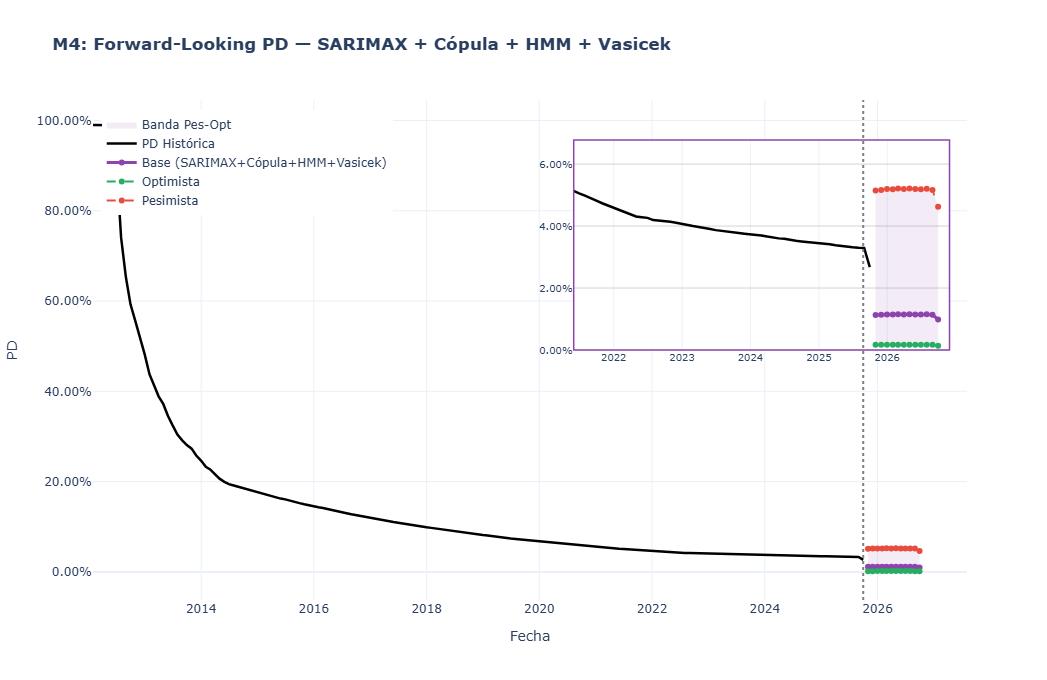

In [60]:
fechas_fut_m4 = pd.date_range(fechas_hist.iloc[-1] + pd.offsets.MonthEnd(1), periods=H, freq='ME')
fig_m4_fl = go.Figure()
def add_m4_traces(fig, eje_x, eje_y, show_leg):
    fig.add_trace(go.Scatter(
        x=list(fechas_fut_m4) + list(fechas_fut_m4)[::-1],
        y=list(vas_m4_pes) + list(vas_m4_opt)[::-1],
        fill='toself', fillcolor='rgba(142,68,173,0.10)',
        line=dict(color='rgba(0,0,0,0)'), 
        name='Banda Pes-Opt', xaxis=eje_x, yaxis=eje_y, showlegend=show_leg
    ))
    # PD Histórica
    fig.add_trace(go.Scatter(
        x=fechas_hist, y=y.values, 
        name='PD Histórica', line=dict(color='black', width=2.5),
        xaxis=eje_x, yaxis=eje_y, showlegend=show_leg
    ))
    # Base
    fig.add_trace(go.Scatter(
        x=fechas_fut_m4, y=vas_m4_base,
        name='Base (SARIMAX+Cópula+HMM+Vasicek)', line=dict(color='#8e44ad', width=3),
        xaxis=eje_x, yaxis=eje_y, showlegend=show_leg
    ))
    # Optimista
    fig.add_trace(go.Scatter(
        x=fechas_fut_m4, y=vas_m4_opt,
        name='Optimista', line=dict(color='#27ae60', dash='dash', width=1.8),
        xaxis=eje_x, yaxis=eje_y, showlegend=show_leg
    ))
    # Pesimista
    fig.add_trace(go.Scatter(
        x=fechas_fut_m4, y=vas_m4_pes,
        name='Pesimista', line=dict(color='#e74c3c', dash='dash', width=1.8),
        xaxis=eje_x, yaxis=eje_y, showlegend=show_leg
    ))
 
add_m4_traces(fig_m4_fl, 'x', 'y', True)
add_m4_traces(fig_m4_fl, 'x2', 'y2', False)
max_val_lupa = max(vas_m4_pes)
 
fig_m4_fl.update_layout(
    title='<b>M4: Forward-Looking PD — SARIMAX + Cópula + HMM + Vasicek</b>',
    xaxis_title='Fecha', yaxis_title='PD', yaxis_tickformat='.2%',
    template='plotly_white', width=1100, height=650,
    hovermode='x unified',
    legend=dict(yanchor='top', y=0.98, xanchor='left', x=0.01),
    xaxis2=dict(
        domain=[0.55, 0.98],
        anchor='y2',
        range=['2021-06-01', fechas_fut_m4[-1] + pd.offsets.MonthEnd(2)],
        dtick="M12", tickfont=dict(size=10)
    ),
    yaxis2=dict(
        domain=[0.50, 0.92],
        anchor='x2',
        range=[0, max_val_lupa * 1.3],
        tickfont=dict(size=10),
        gridcolor='lightgray', showgrid=True,
        tickformat='.2%'
    ),
 
    shapes=[
        dict(type="rect", xref="paper", yref="paper", x0=0.55, y0=0.50, x1=0.98, y1=0.92,
             fillcolor="white", layer="below", line_width=0),
        dict(type="rect", xref="paper", yref="paper", x0=0.55, y0=0.50, x1=0.98, y1=0.92,
             line=dict(color="#8e44ad", width=1.5))
    ]
)
 
fig_m4_fl.add_vline(x=str(fechas_hist.iloc[-1].date()), line_dash='dot', line_color='gray')
fig_m4_fl.show()


## 12. Proyección de PCE Forward-Looking

$$PCE_t = EAD \times PD_t^{M4} \times LGD$$

Se utiliza la PD proyectada por M4 (modelo principal) multiplicada por la EAD total de cartera y la LGD calibrada en 45%.


In [34]:
# PCE forward-looking usando PD proyectada M4
pce_base_fl = EAD * vas_m4_base * LGD
pce_opt_fl  = EAD * vas_m4_opt  * LGD
pce_pes_fl  = EAD * vas_m4_pes  * LGD

# Tabla de proyecciones
df_pce_fl = pd.DataFrame({
    'Fecha':     fechas_fut_m4,
    'PD_Base':   vas_m4_base,
    'PD_Opt':    vas_m4_opt,
    'PD_Pes':    vas_m4_pes,
    'PCE_Base':  pce_base_fl,
    'PCE_Opt':   pce_opt_fl,
    'PCE_Pes':   pce_pes_fl,
})
print(f"EAD Total: ${EAD:,.2f}  |  LGD: {LGD:.0%}")
print()
print("Proyección PCE (12 meses):")
print(df_pce_fl[['Fecha','PD_Base','PD_Opt','PD_Pes','PCE_Base','PCE_Opt','PCE_Pes']].to_string(
    index=False,
    formatters={
        'PD_Base':  '{:.4%}'.format,
        'PD_Opt':   '{:.4%}'.format,
        'PD_Pes':   '{:.4%}'.format,
        'PCE_Base': '${:,.2f}'.format,
        'PCE_Opt':  '${:,.2f}'.format,
        'PCE_Pes':  '${:,.2f}'.format,
    }
))

EAD Total: $93,772.37  |  LGD: 45%

Proyección PCE (12 meses):
     Fecha PD_Base  PD_Opt  PD_Pes PCE_Base PCE_Opt   PCE_Pes
2025-10-31 1.1330% 0.1668% 5.1457%  $478.08  $70.38 $2,171.35
2025-11-30 1.1387% 0.1678% 5.1662%  $480.51  $70.82 $2,180.01
2025-12-31 1.1469% 0.1693% 5.1952%  $483.95  $71.44 $2,192.26
2026-01-31 1.1458% 0.1691% 5.1915%  $483.51  $71.36 $2,190.70
2026-02-28 1.1521% 0.1702% 5.2138%  $486.15  $71.83 $2,200.10
2026-03-31 1.1480% 0.1695% 5.1994%  $484.45  $71.53 $2,194.04
2026-04-30 1.1511% 0.1701% 5.2105%  $485.75  $71.76 $2,198.68
2026-05-31 1.1470% 0.1693% 5.1957%  $484.01  $71.45 $2,192.48
2026-06-30 1.1457% 0.1691% 5.1912%  $483.47  $71.35 $2,190.58
2026-07-31 1.1500% 0.1698% 5.2063%  $485.25  $71.67 $2,196.92
2026-08-31 1.1375% 0.1676% 5.1619%  $480.00  $70.73 $2,178.22
2026-09-30 0.9880% 0.1412% 4.6197%  $416.92  $59.57 $1,949.42


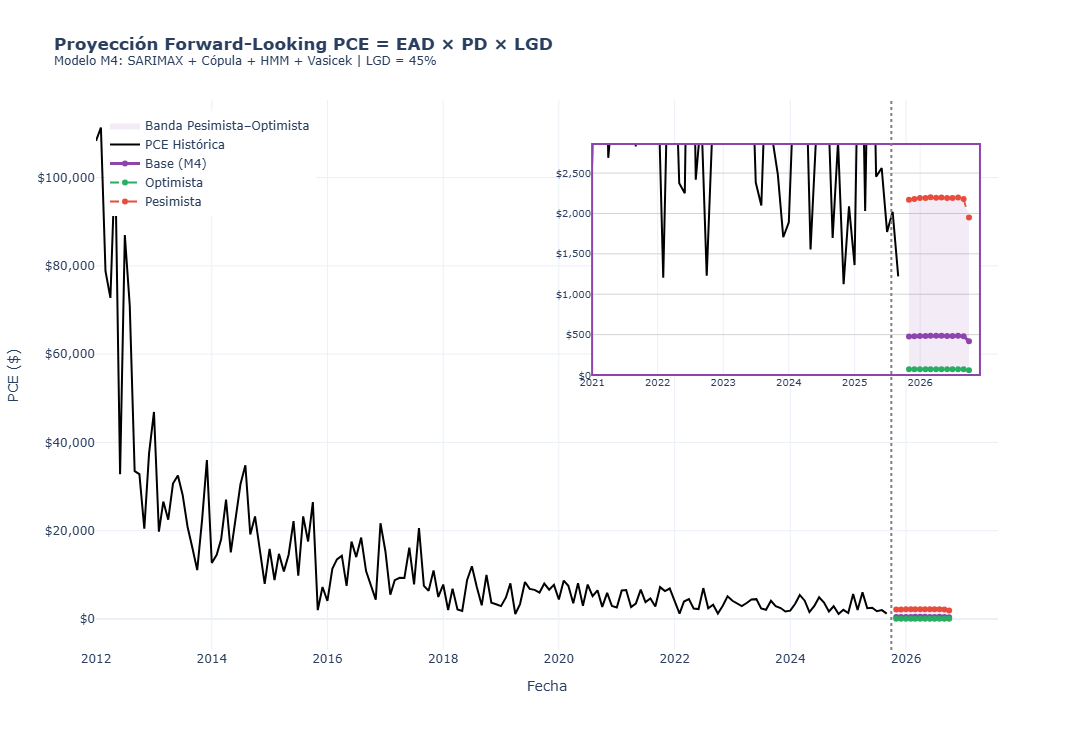

In [57]:
serie_pce_ref = pce_mensual.copy()
serie_pce_ref.index = serie_pce_ref.index.to_timestamp()
fig_pce_fl = go.Figure()
 
def plot_pce_scenarios(fig, x_hist, y_hist, x_proj, y_base, y_opt, y_pes, eje_x, eje_y, show_leg):
    fig.add_trace(go.Scatter(
        x=list(x_proj) + list(x_proj)[::-1],
        y=list(y_pes) + list(y_opt)[::-1],
        fill='toself', fillcolor='rgba(142,68,173,0.10)',
        line=dict(color='rgba(0,0,0,0)'), 
        name='Banda Pesimista–Optimista',
        xaxis=eje_x, yaxis=eje_y, showlegend=show_leg
    ))
    # PCE Histórica
    fig.add_trace(go.Scatter(
        x=x_hist, y=y_hist,
        name='PCE Histórica', line=dict(color='black', width=2),
        xaxis=eje_x, yaxis=eje_y, showlegend=show_leg
    ))
    # Base (M4)
    fig.add_trace(go.Scatter(
        x=x_proj, y=y_base,
        name='Base (M4)', line=dict(color='#8e44ad', width=3),
        xaxis=eje_x, yaxis=eje_y, showlegend=show_leg
    ))
    # Escenarios individuales
    fig.add_trace(go.Scatter(
        x=x_proj, y=y_opt, 
        name='Optimista', line=dict(color='#27ae60', dash='dash', width=1.8),
        xaxis=eje_x, yaxis=eje_y, showlegend=show_leg
    ))
    fig.add_trace(go.Scatter(
        x=x_proj, y=y_pes, 
        name='Pesimista', line=dict(color='#e74c3c', dash='dash', width=1.8),
        xaxis=eje_x, yaxis=eje_y, showlegend=show_leg
    ))
 
plot_pce_scenarios(fig_pce_fl, serie_pce_ref.index, serie_pce_ref.values, 
                   fechas_fut_m4, pce_base_fl, pce_opt_fl, pce_pes_fl, 'x', 'y', True)
 
plot_pce_scenarios(fig_pce_fl, serie_pce_ref.index, serie_pce_ref.values, 
                   fechas_fut_m4, pce_base_fl, pce_opt_fl, pce_pes_fl, 'x2', 'y2', False)
max_pce_pes = max(pce_pes_fl)
 
fig_pce_fl.update_layout(
    title='<b>Proyección Forward-Looking PCE = EAD × PD × LGD</b><br><sup>Modelo M4: SARIMAX + Cópula + HMM + Vasicek | LGD = 45%</sup>',
    xaxis_title='Fecha', yaxis_title='PCE ($)',
    yaxis_tickformat='$,.0f',
    template='plotly_white', 
    width=1100, height=700, 
    hovermode='x unified',
    legend=dict(yanchor='top', y=0.98, xanchor='left', x=0.01),
 
    # Configuración de la Lupa
    xaxis2=dict(
        domain=[0.55, 0.98], anchor='y2',
        range=['2021-01-01', fechas_fut_m4[-1] + pd.offsets.MonthEnd(2)],
        dtick="M12", tickfont=dict(size=10)
    ),
    yaxis2=dict(
        domain=[0.50, 0.92], anchor='x2',
        range=[0, max_pce_pes * 1.3],
        tickfont=dict(size=10), gridcolor='lightgray', showgrid=True,
        tickformat='$,.0f'
    ),
    shapes=[
        dict(type="rect", xref="paper", yref="paper", x0=0.55, y0=0.50, x1=0.98, y1=0.92,
             fillcolor="white", layer="below", line_width=0),
        dict(type="rect", xref="paper", yref="paper", x0=0.55, y0=0.50, x1=0.98, y1=0.92,
             line=dict(color="#8e44ad", width=2))
    ]
)
 
fig_pce_fl.add_vline(x=str(fechas_hist.iloc[-1].date()), line_dash='dot', line_color='gray')
fig_pce_fl.show()

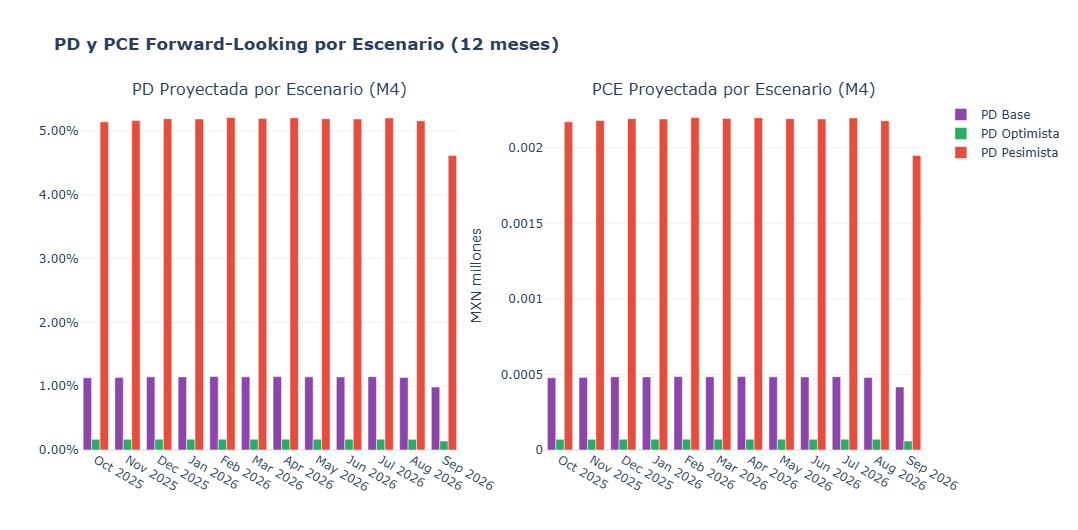

In [36]:
# Gráfica comparativa PD y PCE por escenario (barras por mes)
fig_pce_bar = make_subplots(rows=1, cols=2,
    subplot_titles=['PD Proyectada por Escenario (M4)', 'PCE Proyectada por Escenario (M4)'])

meses_label = [f.strftime('%b %Y') for f in fechas_fut_m4]

fig_pce_bar.add_trace(go.Bar(name='PD Base', x=meses_label, y=vas_m4_base,
    marker_color='#8e44ad'), row=1, col=1)
fig_pce_bar.add_trace(go.Bar(name='PD Optimista', x=meses_label, y=vas_m4_opt,
    marker_color='#27ae60'), row=1, col=1)
fig_pce_bar.add_trace(go.Bar(name='PD Pesimista', x=meses_label, y=vas_m4_pes,
    marker_color='#e74c3c'), row=1, col=1)

fig_pce_bar.add_trace(go.Bar(name='PCE Base', x=meses_label, y=pce_base_fl/1e6,
    marker_color='#8e44ad', showlegend=False), row=1, col=2)
fig_pce_bar.add_trace(go.Bar(name='PCE Optimista', x=meses_label, y=pce_opt_fl/1e6,
    marker_color='#27ae60', showlegend=False), row=1, col=2)
fig_pce_bar.add_trace(go.Bar(name='PCE Pesimista', x=meses_label, y=pce_pes_fl/1e6,
    marker_color='#e74c3c', showlegend=False), row=1, col=2)

fig_pce_bar.update_yaxes(tickformat='.2%', row=1, col=1)
fig_pce_bar.update_yaxes(title_text='MXN millones', row=1, col=2)
fig_pce_bar.update_layout(title='<b>PD y PCE Forward-Looking por Escenario (12 meses)</b>',
    barmode='group', template='plotly_white', width=1200, height=500)
fig_pce_bar.show()


In [37]:
# Tabla resumen PCE acumulada por escenario
print("RESUMEN PCE ACUMULADA 12 MESES")
print("-" * 60)
print(f"EAD Total         : ${EAD:>20,.2f}")
print(f"LGD               : {LGD:.0%}")
print(f"Horizonte         : 12 meses")
print()
print(f"{'Escenario':<15} {'PD Promedio':>15} {'PCE Acumulada':>20} {'PCE / EAD':>12}")
print("-" * 65)
for label, pd_arr, pce_arr in [
    ('Base',      vas_m4_base, pce_base_fl),
    ('Optimista', vas_m4_opt,  pce_opt_fl),
    ('Pesimista', vas_m4_pes,  pce_pes_fl),
]:
    pce_total = pce_arr.sum()
    print(f"{label:<15} {np.mean(pd_arr):>14.4%} ${pce_total:>19,.2f} {pce_total/EAD:>11.4%}")
print("=" * 60)


RESUMEN PCE ACUMULADA 12 MESES
------------------------------------------------------------
EAD Total         : $           93,772.37
LGD               : 45%
Horizonte         : 12 meses

Escenario           PD Promedio        PCE Acumulada    PCE / EAD
-----------------------------------------------------------------
Base                   1.1320% $           5,732.05     6.1127%
Optimista              0.1667% $             843.88     0.8999%
Pesimista              5.1414% $          26,034.74    27.7638%


## 13. Comparación de los 4 modelos (train/test)

In [38]:
inv_logit = lambda x: np.exp(np.array(x)) / (1 + np.exp(np.array(x)))

H_test   = 12
df_train = df.iloc[:-H_test].copy()
df_test  = df.iloc[-H_test:].copy()

y_train       = df_train['PD'].clip(0.01, 0.99)
y_test        = df_test['PD'].clip(0.01, 0.99)
y_logit_train = np.log(y_train / (1 - y_train))

X_train     = df_train[X_cols]
X_test      = df_test[X_cols]
X_mu_tr     = X_train.mean()
X_sig_tr    = X_train.std()
X_train_std = (X_train - X_mu_tr) / X_sig_tr
X_test_std  = (X_test  - X_mu_tr) / X_sig_tr
y_true      = y_test.values

print(f'Train: {len(df_train)} obs  {df_train["Fecha"].iloc[0].date()} -> {df_train["Fecha"].iloc[-1].date()}')
print(f'Test:  {len(df_test)} obs   {df_test["Fecha"].iloc[0].date()}  -> {df_test["Fecha"].iloc[-1].date()}')


Train: 153 obs  2012-01-31 -> 2024-09-30
Test:  12 obs   2024-10-31  -> 2025-09-30


In [39]:
# M1 test
m1t = SARIMAX(y_logit_train, exog=X_train_std, order=(1,0,1),
              seasonal_order=(1,0,1,12),
              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

serie_tr_m1 = y_logit_train.values.reshape(-1,1)
bic_m1_best, k_m1 = np.inf, 2
for k in [2, 3]:
    _m = hmm.GaussianHMM(n_components=k, covariance_type='full', n_iter=1000, random_state=42).fit(serie_tr_m1)
    _b = -2*_m.score(serie_tr_m1) + np.log(len(serie_tr_m1))*(k**2+2*k-1)
    if _b < bic_m1_best:
        bic_m1_best, k_m1 = _b, k

hmm_m1t = hmm.GaussianHMM(n_components=k_m1, covariance_type='full', n_iter=1000, random_state=42)
hmm_m1t.fit(serie_tr_m1)
est_m1t = hmm_m1t.predict(serie_tr_m1)[-1]
med_m1t = hmm_m1t.means_.flatten()

fc_m1t = m1t.forecast(H_test, exog=X_test_std).values
cp = np.zeros(k_m1); cp[est_m1t] = 1.0
hmm_adj_m1 = []
for _ in range(H_test):
    cp = cp @ hmm_m1t.transmat_
    hmm_adj_m1.append(np.dot(cp, med_m1t))

pd_m1_test = np.clip(inv_logit(fc_m1t + np.array(hmm_adj_m1)), 1e-6, 1-1e-6)
print(f'M1 — RMSE={np.sqrt(np.mean((y_true-pd_m1_test)**2)):.6f}  MAE={np.mean(np.abs(y_true-pd_m1_test)):.6f}')


M1 — RMSE=0.031293  MAE=0.031230


In [43]:
# M2 test
m2t_ols = sm.OLS(y_logit_train, sm.add_constant(X_train[X_cols_m2])).fit()
bic_m2_best, k_m2 = np.inf, 2
for k in [2, 3]:
    _m = hmm.GaussianHMM(n_components=k, covariance_type='full', n_iter=1000, random_state=42).fit(serie_tr_m1)
    _b = -2*_m.score(serie_tr_m1) + np.log(len(serie_tr_m1))*(k**2+2*k-1)
    if _b < bic_m2_best:
        bic_m2_best, k_m2 = _b, k

hmm_m2t = hmm.GaussianHMM(n_components=k_m2, covariance_type='full', n_iter=1000, random_state=42)
hmm_m2t.fit(serie_tr_m1)
est_m2t = hmm_m2t.predict(serie_tr_m1)[-1]
med_m2t = hmm_m2t.means_.flatten()

fc_ols_logit = m2t_ols.predict(sm.add_constant(X_test[X_cols_m2], has_constant='add'))
cp = np.zeros(k_m2); cp[est_m2t] = 1.0
hmm_adj_m2 = []
for _ in range(H_test):
    cp = cp @ hmm_m2t.transmat_
    hmm_adj_m2.append(np.dot(cp, med_m2t))

pd_m2_test = np.clip(inv_logit(fc_ols_logit.values + np.array(hmm_adj_m2)), 1e-6, 1-1e-6)
print(f'M2 — RMSE={np.sqrt(np.mean((y_true-pd_m2_test)**2)):.6f}  MAE={np.mean(np.abs(y_true-pd_m2_test)):.6f}')


M2 — RMSE=0.030479  MAE=0.030445


In [40]:
# M3 test
data_tr_m3       = df_train[['PD']+X_cols].copy()
data_tr_m3['PD'] = y_train.values
Z_tr_m3          = data_tr_m3.apply(lambda s: spn.ppf(emp_uniform(s)))
m3t_reg          = sm.OLS(Z_tr_m3['PD'], sm.add_constant(Z_tr_m3[X_cols])).fit()

Z_te_m3    = pd.DataFrame({c: spn.ppf(cond_uniform(X_test[c].values, X_train[c].values)) for c in X_cols})
Z_pd_te    = m3t_reg.predict(sm.add_constant(Z_te_m3, has_constant='add'))
U_te_m3    = spn.cdf(Z_pd_te)
pd_m3_test = np.clip(np.quantile(y_train, np.clip(U_te_m3, 0.01, 0.99)), 1e-6, 1-1e-6)
print(f'M3 — RMSE={np.sqrt(np.mean((y_true-pd_m3_test)**2)):.6f}  MAE={np.mean(np.abs(y_true-pd_m3_test)):.6f}')


M3 — RMSE=0.004722  MAE=0.004319


In [41]:
# M4 test
m4t_sar   = SARIMAX(y_logit_train, exog=X_train_std, order=(1,0,1),
                     seasonal_order=(1,0,1,12),
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
resid_m4t = m4t_sar.resid.values
n_r       = len(resid_m4t)
X_tr_aln  = X_train_std.iloc[-n_r:].reset_index(drop=True)

resid_m4t_std = (resid_m4t - resid_m4t.mean()) / resid_m4t.std()
data_cop_m4t  = pd.DataFrame({'resid': resid_m4t_std})
for c in X_cols:
    data_cop_m4t[c] = X_tr_aln[c].values

Z_cop_m4t      = data_cop_m4t.apply(lambda s: spn.ppf(emp_uniform(s)))
Sig_m4t        = Z_cop_m4t.corr().values
Sig_rX_m4t     = Sig_m4t[0, 1:]
Sig_XX_m4t     = Sig_m4t[1:, 1:]
Sig_XX_inv_m4t = np.linalg.inv(Sig_XX_m4t)

eps_cop_hist_m4t = np.quantile(resid_m4t,
    np.clip(spn.cdf(Z_cop_m4t[X_cols].values @ Sig_XX_inv_m4t @ Sig_rX_m4t), 0.01, 0.99))
resid_corr_m4t   = resid_m4t - eps_cop_hist_m4t

serie_rc_m4t = resid_corr_m4t.reshape(-1, 1)
bic_best_m4t, k_m4t = np.inf, 2
for k in [2, 3]:
    _m = hmm.GaussianHMM(n_components=k, covariance_type='full', n_iter=1000, random_state=42).fit(serie_rc_m4t)
    _b = -2*_m.score(serie_rc_m4t) + np.log(len(serie_rc_m4t))*(k**2+2*k-1)
    if _b < bic_best_m4t:
        bic_best_m4t, k_m4t = _b, k

hmm_m4t = hmm.GaussianHMM(n_components=k_m4t, covariance_type='full', n_iter=1000, random_state=42)
hmm_m4t.fit(serie_rc_m4t)
est_m4t = hmm_m4t.predict(serie_rc_m4t)[-1]
med_m4t = hmm_m4t.means_.flatten()

fc_m4t = m4t_sar.forecast(H_test, exog=X_test_std).values
eps_cop_te_m4 = np.zeros(H_test)
for t in range(H_test):
    z_x_t = np.array([spn.ppf(cond_uniform(X_test_std[c].values[t:t+1], X_tr_aln[c].values)[0]) for c in X_cols])
    z_r_t = Sig_rX_m4t @ Sig_XX_inv_m4t @ z_x_t
    eps_cop_te_m4[t] = np.quantile(resid_m4t, np.clip(spn.cdf(z_r_t), 0.01, 0.99))

cp = np.zeros(k_m4t); cp[est_m4t] = 1.0
hmm_adj_m4t = []
for _ in range(H_test):
    cp = cp @ hmm_m4t.transmat_
    hmm_adj_m4t.append(np.dot(cp, med_m4t))

pd_m4_test = np.clip(inv_logit(fc_m4t + eps_cop_te_m4 + np.array(hmm_adj_m4t)), 1e-6, 1-1e-6)
print(f'M4 — RMSE={np.sqrt(np.mean((y_true-pd_m4_test)**2)):.6f}  MAE={np.mean(np.abs(y_true-pd_m4_test)):.6f}')


M4 — RMSE=0.003001  MAE=0.002598


In [46]:
rmse_f = lambda a, b: np.sqrt(np.mean((np.array(a)-np.array(b))**2))
mae_f  = lambda a, b: np.mean(np.abs(np.array(a)-np.array(b)))

metricas = pd.DataFrame({
    'Modelo': ['M1: SARIMAX + HMM + Vasicek','M2: OLS + HMM + Vasicek',
               'M3: Copula + Regresión + Vasicek','M4: SARIMAX + Copula + HMM + Vasicek'],
    'RMSE': [rmse_f(y_true,pd_m1_test), rmse_f(y_true,pd_m2_test),
             rmse_f(y_true,pd_m3_test), rmse_f(y_true,pd_m4_test)],
    'MAE':  [mae_f(y_true,pd_m1_test),  mae_f(y_true,pd_m2_test),
             mae_f(y_true,pd_m3_test),  mae_f(y_true,pd_m4_test)],
}).set_index('Modelo')

metricas['Rank_RMSE']  = metricas['RMSE'].rank().astype(int)
metricas['Rank_MAE']   = metricas['MAE'].rank().astype(int)
metricas['Rank_Total'] = metricas['Rank_RMSE'] + metricas['Rank_MAE']
metricas = metricas.sort_values('Rank_Total')
print(metricas[['RMSE','MAE','Rank_RMSE','Rank_MAE','Rank_Total']].round(6).to_string())


                                          RMSE       MAE  Rank_RMSE  Rank_MAE  Rank_Total
Modelo                                                                                   
M4: SARIMAX + Copula + HMM + Vasicek  0.003001  0.002598          1         1           2
M3: Copula + Regresión + Vasicek      0.004722  0.004319          2         2           4
M2: OLS + HMM + Vasicek               0.030479  0.030445          3         3           6
M1: SARIMAX + HMM + Vasicek           0.031293  0.031230          4         4           8


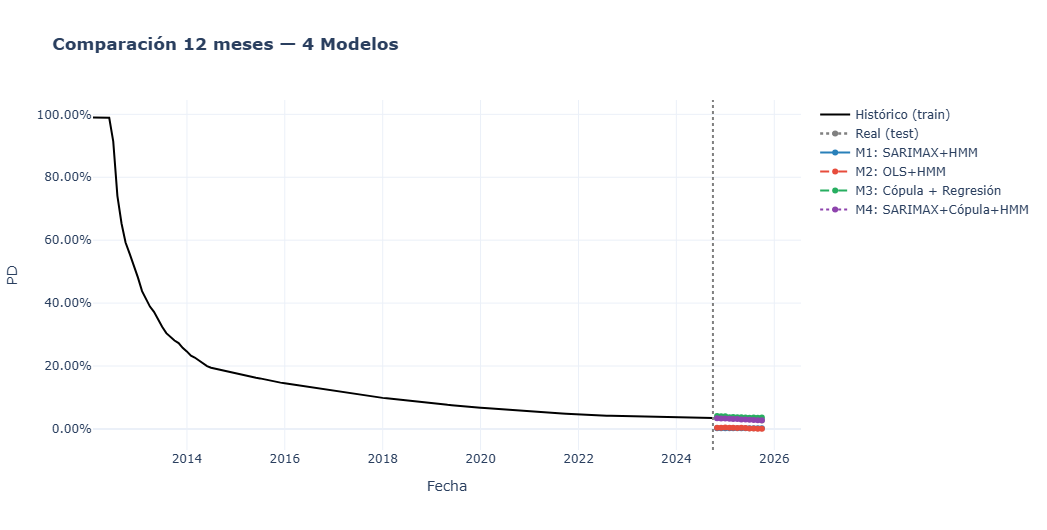

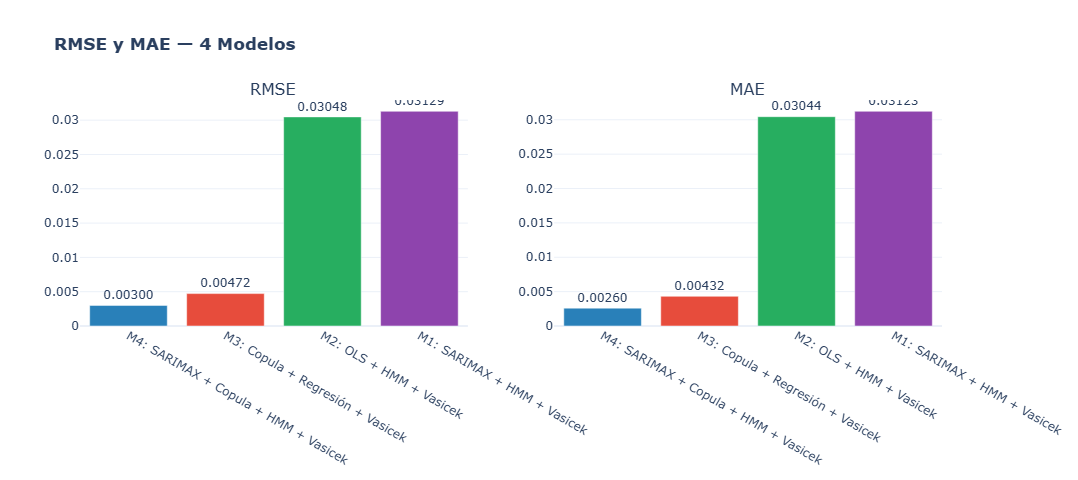


VaR y ES — Escenario Base 
                        PD_media        VaR_MC         ES_MC
M1: SARIMAX+HMM           0.0005  6.446304e+04  1.031536e+05
M2: OLS+HMM               0.0002  2.985373e+04  5.010819e+04
M3: Cópula+Regresión      0.0270  1.908930e+06  2.405780e+06
M4: SARIMAX+Cópula+HMM    0.0113  9.687030e+05  1.288308e+06


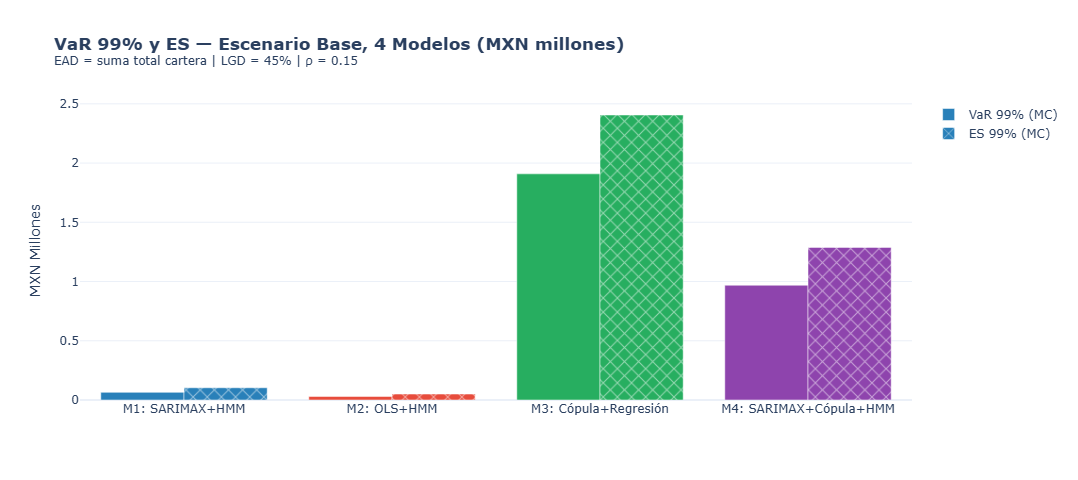


VaR y ES — Escenario Optimista 
                        PD_media       VaR_MC         ES_MC
M1: SARIMAX+HMM           0.0000    4091.5413  7.729278e+03
M2: OLS+HMM               0.0000    1280.0841  2.585501e+03
M3: Cópula+Regresión      0.0101  885332.5954  1.185474e+06
M4: SARIMAX+Cópula+HMM    0.0017  196887.7627  2.931041e+05


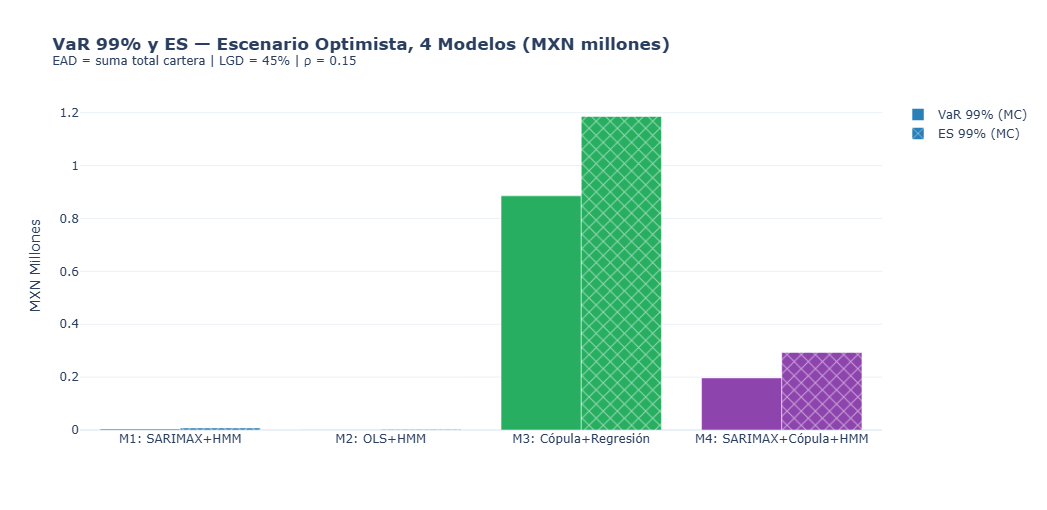


VaR y ES — Escenario Pesimista 
                        PD_media        VaR_MC         ES_MC
M1: SARIMAX+HMM           0.0055  5.411504e+05  7.512895e+05
M2: OLS+HMM               0.0027  2.929832e+05  4.246104e+05
M3: Cópula+Regresión      0.0896  4.522195e+06  5.273236e+06
M4: SARIMAX+Cópula+HMM    0.0514  3.069980e+06  3.713211e+06


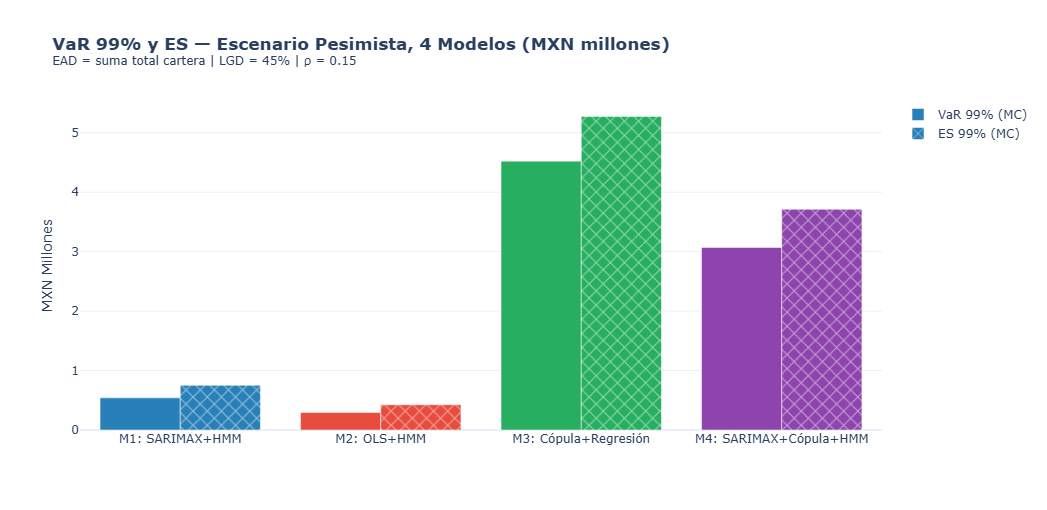

In [59]:
cols_4 = ['#2980b9','#e74c3c','#27ae60','#8e44ad']
mods_4 = metricas.index.tolist()

# --- Proyecciones vs real

fig_cmp = go.Figure()
fig_cmp.add_trace(go.Scatter(x=df_train['Fecha'], y=y_train.values,
    name='Histórico (train)', line=dict(color='black', width=2)))
fig_cmp.add_trace(go.Scatter(x=df_test['Fecha'], y=y_true,
    name='Real (test)', line=dict(color='gray', width=2.5, dash='dot')))
for pd_test, nombre, color, dash in [
    (pd_m1_test, 'M1: SARIMAX+HMM',        '#2980b9', 'solid'),
    (pd_m2_test, 'M2: OLS+HMM',             '#e74c3c', 'dash'),
    (pd_m3_test, 'M3: Cópula + Regresión',  '#27ae60', 'dash'),
    (pd_m4_test, 'M4: SARIMAX+Cópula+HMM', '#8e44ad', 'dot'),
]:
    fig_cmp.add_trace(go.Scatter(x=df_test['Fecha'], y=pd_test,
        name=nombre, line=dict(color=color, width=2, dash=dash)))
fig_cmp.add_vline(x=str(df_train['Fecha'].iloc[-1].date()), line_dash='dot', line_color='gray')
fig_cmp.update_layout(title='<b>Comparación 12 meses — 4 Modelos</b>',
    xaxis_title='Fecha', yaxis_title='PD', yaxis_tickformat='.2%',
    template='plotly_white', width=1100, height=500, hovermode='x unified')
fig_cmp.show()

# --- RMSE / MAE

fig_bar = make_subplots(rows=1, cols=2, subplot_titles=['RMSE','MAE'])
for ci, met in enumerate(['RMSE','MAE'], 1):
    vals      = [metricas.loc[m, met] for m in mods_4 if m in metricas.index]
    mods_sort = [m for m in mods_4 if m in metricas.index]
    fig_bar.add_trace(go.Bar(x=mods_sort, y=vals, marker_color=cols_4, showlegend=False,
        text=[f'{v:.5f}' for v in vals], textposition='outside'), row=1, col=ci)
fig_bar.update_layout(title='<b>RMSE y MAE — 4 Modelos</b>',
    template='plotly_white', height=480, width=1050)
fig_bar.show()

# ---- VaR y ES: 3 escenarios x 4 modelos (EAD = suma total cartera)

escenarios_var = {
    'Base':      [vas_base,    vas_m2_base, vas_m3_base, vas_m4_base],
    'Optimista': [vas_opt,     vas_m2_opt,  vas_m3_opt,  vas_m4_opt],
    'Pesimista': [vas_pes,     vas_m2_pes,  vas_m3_pes,  vas_m4_pes],
}
modelos_label = ['M1: SARIMAX+HMM', 'M2: OLS+HMM', 'M3: Cópula+Regresión', 'M4: SARIMAX+Cópula+HMM']

colores_esc = {'Base': '#2c3e50', 'Optimista': '#27ae60', 'Pesimista': '#e74c3c'}

for esc_nombre, vas_list in escenarios_var.items():
    res_list = [var_es_vasicek(v) for v in vas_list]
    res_df   = pd.DataFrame(res_list, index=modelos_label)

    print(f"\n{'='*60}")
    print(f"VaR y ES — Escenario {esc_nombre} ")
    print('='*60)
    print(res_df[['PD_media','VaR_MC','ES_MC']].round(4).to_string())

    color = colores_esc[esc_nombre]
    fig_esc = go.Figure()
    fig_esc.add_trace(go.Bar(
        name='VaR 99% (MC)', x=modelos_label,
        y=res_df['VaR_MC']/1e6, marker_color=cols_4))
    fig_esc.add_trace(go.Bar(
        name='ES 99% (MC)', x=modelos_label,
        y=res_df['ES_MC']/1e6, marker_color=cols_4,
        marker_pattern_shape='x'))
    fig_esc.update_layout(
        title=f'<b>VaR 99% y ES — Escenario {esc_nombre}, 4 Modelos (MXN millones)</b>'
              f'<br><sup>EAD = suma total cartera | LGD = 45% | ρ = 0.15</sup>',
        barmode='group', template='plotly_white',
        height=480, width=1050, yaxis_title='MXN Millones')
    fig_esc.show()
